<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 10px;">
    <h1 style="color: #e94560; font-size: 2.4em; margin:0; font-weight:700; letter-spacing:1px;">🚗 US Accidents — Exploratory Data Analysis</h1>
    <p style="color: #a8b2d8; font-size: 1.1em; margin-top: 12px; margin-bottom: 0;">
        A comprehensive EDA on the US Accidents dataset covering univariate, bivariate, and findings-driven analysis.
    </p>
</div>

| 📌 | Detail |
|---|---|
| **Dataset** | US Accidents (Cleaned) |
| **Rows** | ~7.7 Million |
| **Columns** | 46 |
| **Analysis Type** | Univariate + Bivariate EDA |
| **Tools Used** | Python, Pandas, NumPy, Matplotlib, Seaborn |
| **Author** | Raj |

## 📋 Table of Contents

1. [📦 Import Libraries](#1)
2. [📂 Load Dataset](#2)
3. [🔢 Column Classification by Dtype](#3)
4. [📊 Univariate Analysis — Numerical Columns](#4)
   - Start_Lat · Start_Lng · End_Lat · End_Lng
   - Distance · Temperature · Wind_Chill · Humidity
   - Pressure · Wind_Speed · Precipitation
5. [📝 Univariate Analysis — Categorical Columns](#5)
   - Source · Street · County · State · Timezone
   - Severity · Weather Condition · Wind Direction · Sunrise_Sunset · Civil_Twilight
6. [🔎 Key Findings — Univariate](#6)
7. [📈 Bivariate Analysis](#7)
   - Weather Condition × Severity
   - State × Severity
   - Timezone × Severity
   - Sunrise_Sunset × Severity
   - Temperature Distribution by Severity
   - Humidity Distribution by Severity
   - Distance by Severity
   - Top Streets by Accident Count
8. [💡 Final Insights Summary](#8)

<a id="1"></a>
## 📦 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


<a id="2"></a>
## 📂 2. Load Dataset

In [3]:
df = pd.read_csv('Clened_Dataset.csv')
print(f"Shape : {df.shape}")
print(f"Rows  : {df.shape[0]:,}")
print(f"Cols  : {df.shape[1]}")
df.head()

Shape : (7728394, 48)
Rows  : 7,728,394
Cols  : 48


,Unnamed: 0,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,...,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Accident_Time
0,0,1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,39.865147,-84.058723,...,False,False,False,False,False,Night,Night,Night,Night,0 days 05:14:00
1,1,2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,39.928059,-82.831184,...,False,False,False,False,False,Night,Night,Night,Day,0 days 00:30:00
2,2,3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,39.063148,-84.032608,...,False,False,False,True,False,Night,Night,Day,Day,0 days 00:30:00
3,3,4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,39.747753,-84.205582,...,False,False,False,False,False,Night,Day,Day,Day,0 days 00:30:00
4,4,5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,39.627781,-84.188354,...,False,False,False,True,False,Day,Day,Day,Day,0 days 00:30:00


<a id="3"></a>
## 🔢 3. Column Classification by Dtype

Columns are split into **numerical** and **categorical** groups for targeted analysis.

**Numerical columns:** `ID`, `Severity`, `Start_Lat`, `Start_Lng`, `End_Lat`, `End_Lng`, `Distance(mi)`, `Zipcode`, `Temperature(F)`, `Wind_Chill(F)`, `Humidity(%)`, `Pressure(in)`, `Visibility(mi)`, `Wind_Speed(mph)`, `Precipitation(in)`

**Categorical columns:** `Source`, `Start_Time`, `End_Time`, `Description`, `Street`, `City`, `County`, `State`, `Country`, `Timezone`, `Airport_Code`, `Weather_Timestamp`, `Wind_Direction`, `Weather_Condition`, `Amenity`, `Bump`, `Crossing`, `Give_Way`, `Junction`, `No_Exit`, `Railway`, `Roundabout`, `Station`, `Stop`, `Traffic_Calming`, `Traffic_Signal`, `Turning_Loop`, `Sunrise_Sunset`, `Civil_Twilight`, `Nautical_Twilight`, `Astronomical_Twilight`

In [4]:
numerical   = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
print(f"Numerical columns   : {len(numerical)}")
print(f"Categorical columns : {len(categorical)}")

Numerical columns   : 16
Categorical columns : 32


<a id="4"></a>
## 📊 4. Univariate Analysis — Numerical Columns

For each numerical column we look at:
- **Statistical summary** — mean, std, quartiles
- **Distribution** — histogram to detect skewness
- **Outliers** — boxplot
- **Skewness value** — quantified direction

In [5]:
def give_Summary(col_name):
    print(f"{'='*60}")
    print(f"  Column : {col_name}")
    print(f"{'='*60}\n")

    print("📌 Statistical Summary")
    print(df[col_name].describe().round(4))
    print()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Histogram
    axes[0].hist(df[col_name].dropna(), bins=50, color='#4a90d9', edgecolor='white', alpha=0.85)
    axes[0].set_title(f'Distribution — {col_name}', fontsize=13, fontweight='bold')
    axes[0].set_xlabel(col_name)
    axes[0].set_ylabel('Frequency')

    # Boxplot
    axes[1].boxplot(df[col_name].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor='#f0a500', color='#333'),
                    medianprops=dict(color='red', linewidth=2))
    axes[1].set_title(f'Outlier Check — {col_name}', fontsize=13, fontweight='bold')
    axes[1].set_xlabel(col_name)

    plt.tight_layout()
    plt.show()

    skew_val = df[col_name].skew()
    direction = "Right (positive)" if skew_val > 0.5 else "Left (negative)" if skew_val < -0.5 else "Approximately symmetric"
    print(f"📐 Skewness : {skew_val:.4f}  →  {direction}\n")

## 4.1 Start_Lat

| Observation | Detail |
|---|---|
| **Skewness** | Left skewed (negatively skewed distribution) |
| **Outliers** | None detected |
| **Missing Values** | None |


  Column : Start_Lat

📌 Statistical Summary
count    7.728394e+06
mean     3.620120e+01
std      5.076100e+00
min      2.455480e+01
25%      3.339960e+01
50%      3.582400e+01
75%      4.008500e+01
max      4.900220e+01
Name: Start_Lat, dtype: float64



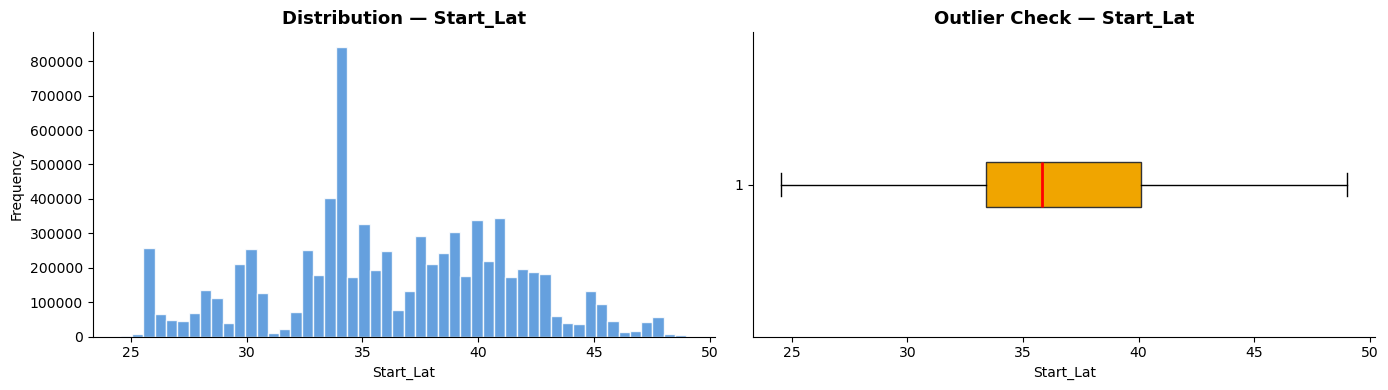

📐 Skewness : -0.0722  →  Approximately symmetric



In [6]:
give_Summary('Start_Lat')

## 4.2 Start_Lng

| Observation | Detail |
|---|---|
| **Distribution Shape** | Bimodal — two peaks visible (East & West coast accident clusters) |
| **Skewness** | Left skewed |
| **Outliers** | None significant |


  Column : Start_Lng

📌 Statistical Summary
count    7.728394e+06
mean    -9.470250e+01
std      1.739180e+01
min     -1.246238e+02
25%     -1.172194e+02
50%     -8.776660e+01
75%     -8.035370e+01
max     -6.711320e+01
Name: Start_Lng, dtype: float64



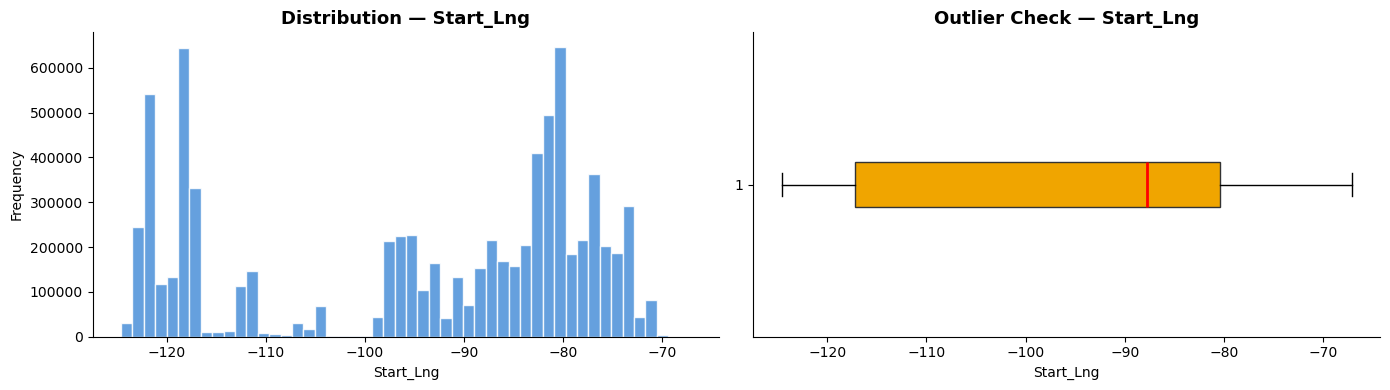

📐 Skewness : -0.4829  →  Approximately symmetric



In [7]:
give_Summary('Start_Lng')

## 4.3 End_Lat

| Observation | Detail |
|---|---|
| **Skewness** | Negatively skewed |
| **Outliers** | None detected |


  Column : End_Lat

📌 Statistical Summary
count    7.728394e+06
mean     3.620130e+01
std      5.076200e+00
min      2.455480e+01
25%      3.340050e+01
50%      3.582400e+01
75%      4.008490e+01
max      4.907500e+01
Name: End_Lat, dtype: float64



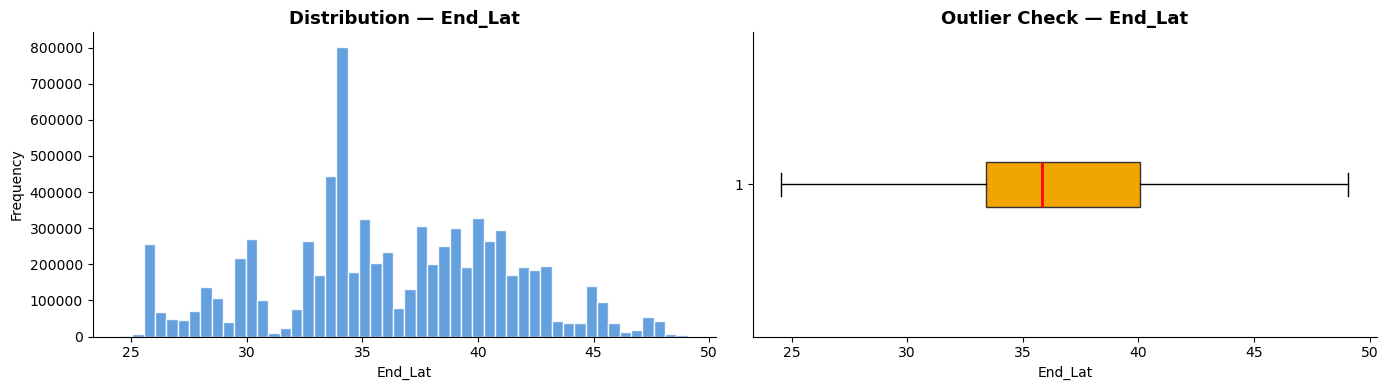

📐 Skewness : -0.0722  →  Approximately symmetric



In [8]:
give_Summary('End_Lat')

## 4.4 End_Lng

| Observation | Detail |
|---|---|
| **Skewness** | Negatively skewed |
| **Outliers** | None detected |


  Column : End_Lng

📌 Statistical Summary
count    7.728394e+06
mean    -9.470240e+01
std      1.739160e+01
min     -1.246238e+02
25%     -1.172189e+02
50%     -8.776750e+01
75%     -8.035430e+01
max     -6.710920e+01
Name: End_Lng, dtype: float64



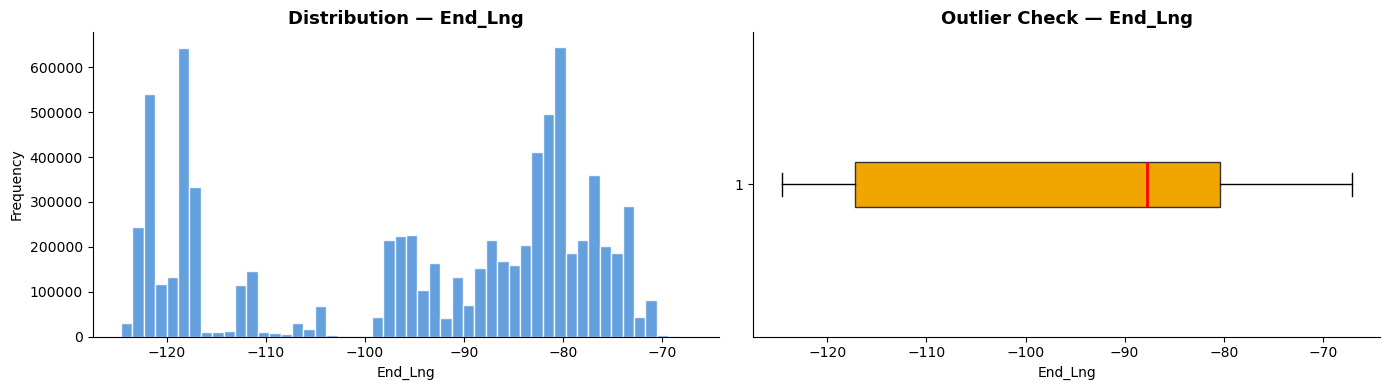

📐 Skewness : -0.4829  →  Approximately symmetric



In [9]:
give_Summary('End_Lng')

## 4.5 Distance(mi)

| Observation | Detail |
|---|---|
| **Skewness** | Highly right skewed — majority of values cluster near 0 |
| **Outliers** | Significant outliers present |
| **Key Pattern** | Most values are 0 (accident happened at a single point) |
| **Extreme Values** | Only ~15,000 records have Distance > 15 miles |


  Column : Distance(mi)

📌 Statistical Summary
count    7.728394e+06
mean     5.618000e-01
std      1.776800e+00
min      0.000000e+00
25%      0.000000e+00
50%      3.000000e-02
75%      4.640000e-01
max      4.417500e+02
Name: Distance(mi), dtype: float64



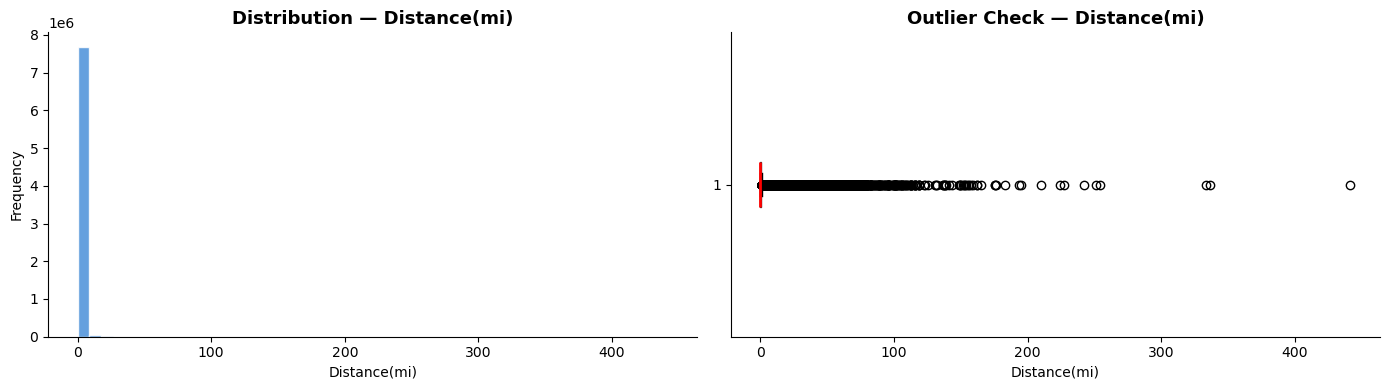

📐 Skewness : 20.3858  →  Right (positive)



In [10]:
give_Summary('Distance(mi)')

## 4.6 Temperature(F)

| Observation | Detail |
|---|---|
| **Skewness** | Left skewed distribution |
| **Outliers** | ~35,000 outliers at extreme cold end (< 5°F) |
| **Key Pattern** | Most accidents occur in the moderate temperature range |


  Column : Temperature(F)

📌 Statistical Summary
count    7.728394e+06
mean     6.171280e+01
std      1.881420e+01
min     -8.900000e+01
25%      5.000000e+01
50%      6.400000e+01
75%      7.600000e+01
max      2.070000e+02
Name: Temperature(F), dtype: float64



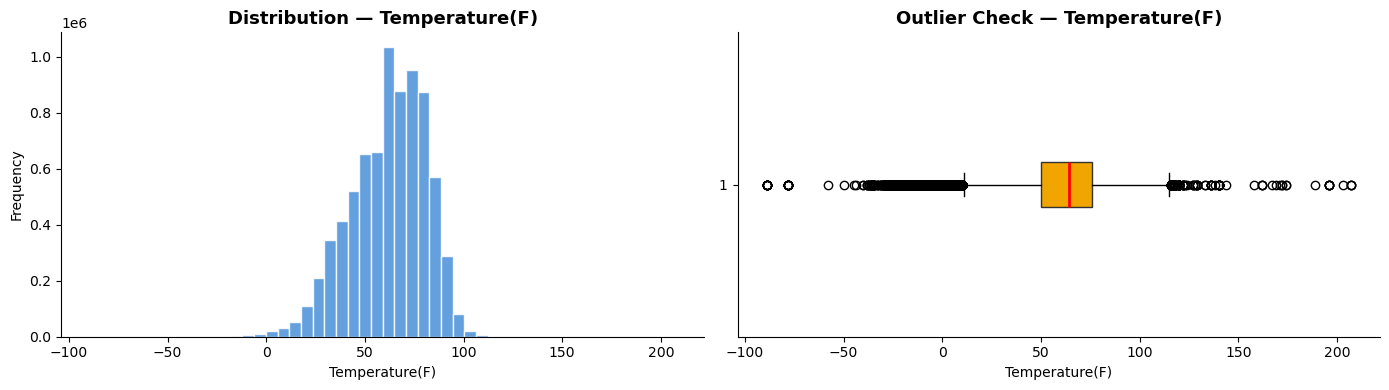

📐 Skewness : -0.5269  →  Left (negative)



In [11]:
give_Summary('Temperature(F)')

## 4.7 Wind_Chill(F)

| Observation | Detail |
|---|---|
| **Skewness** | Left skewed |
| **Outliers** | Present at the lower extreme |


  Column : Wind_Chill(F)

📌 Statistical Summary
count    7.728394e+06
mean     5.922070e+01
std      1.934770e+01
min     -8.900000e+01
25%      5.200000e+01
50%      6.200000e+01
75%      7.100000e+01
max      2.070000e+02
Name: Wind_Chill(F), dtype: float64



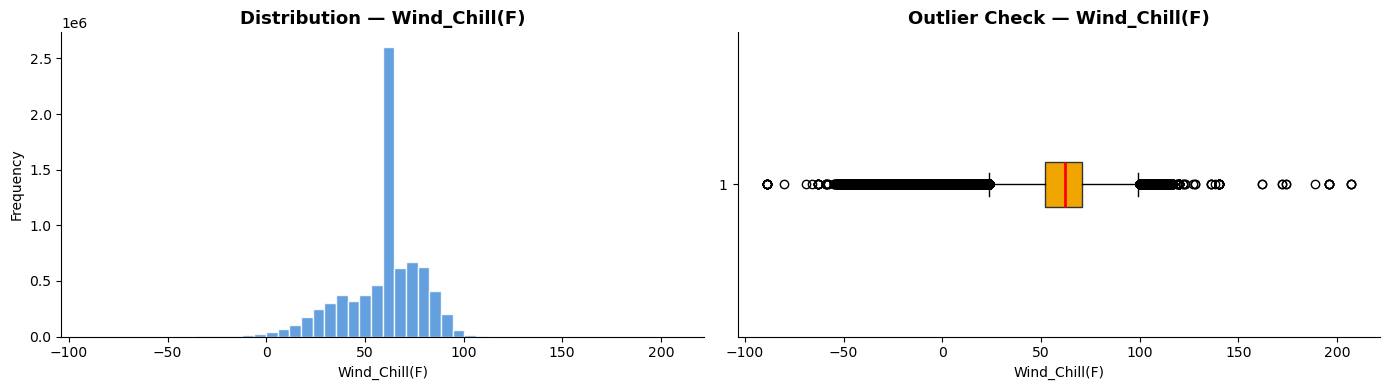

📐 Skewness : -0.9216  →  Left (negative)



In [12]:
give_Summary('Wind_Chill(F)')

## 4.8 Humidity(%)

| Observation | Detail |
|---|---|
| **Skewness** | Left skewed, approximately normal shape |
| **Outliers** | None significant |


  Column : Humidity(%)

📌 Statistical Summary
count    7.728394e+06
mean     6.487990e+01
std      2.256470e+01
min      1.000000e+00
25%      4.900000e+01
50%      6.700000e+01
75%      8.400000e+01
max      1.000000e+02
Name: Humidity(%), dtype: float64



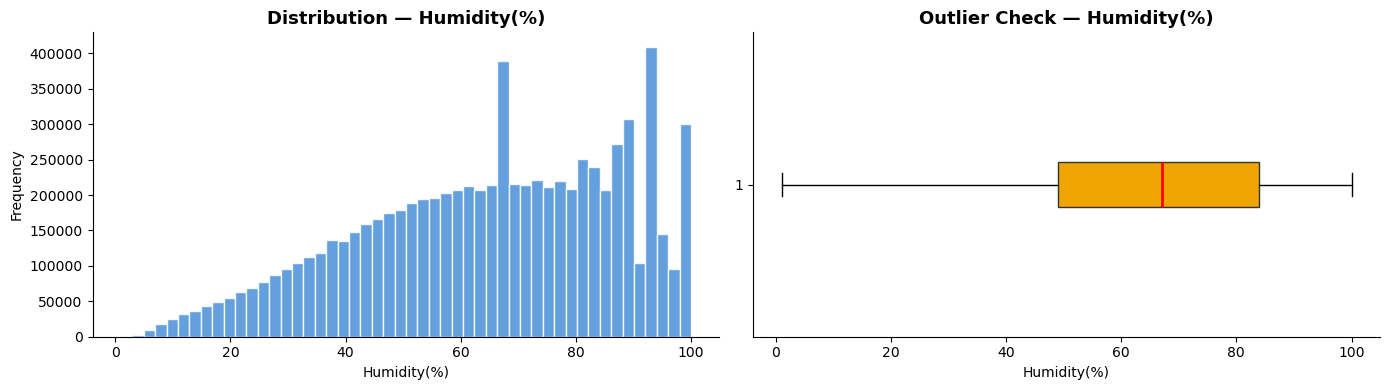

📐 Skewness : -0.4057  →  Approximately symmetric



In [13]:
give_Summary('Humidity(%)')

## 4.9 Pressure(in)

| Observation | Detail |
|---|---|
| **Skewness** | Highly left skewed |
| **Outliers** | ~70,000 outliers detected |
| **Data Quality Issue** | 14 rows with Pressure = 0 — physically impossible, likely data entry errors |


  Column : Pressure(in)

📌 Statistical Summary
count    7.728394e+06
mean     2.954810e+01
std      1.017800e+00
min      0.000000e+00
25%      2.900000e+01
50%      3.000000e+01
75%      3.000000e+01
max      5.900000e+01
Name: Pressure(in), dtype: float64



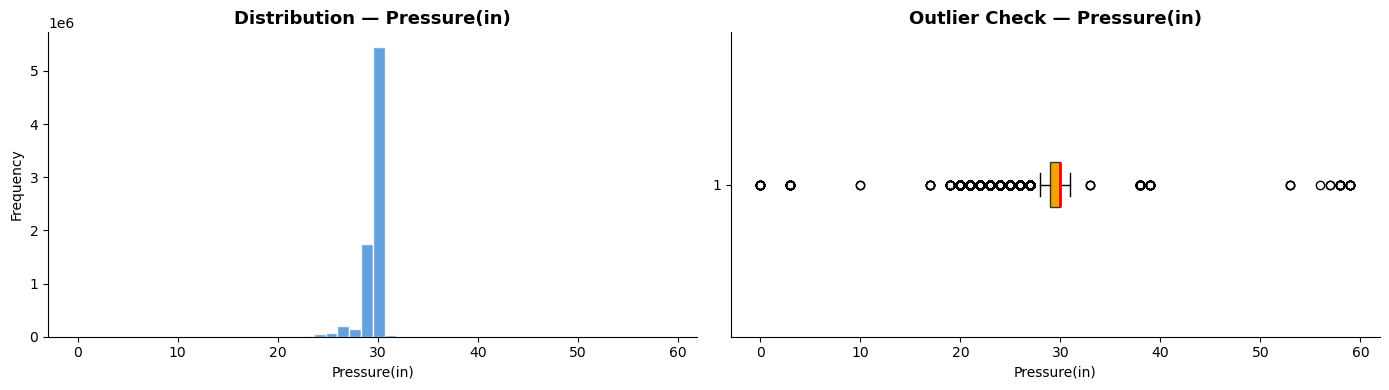

📐 Skewness : -3.5761  →  Left (negative)



In [14]:
give_Summary('Pressure(in)')

## 4.10 Wind_Speed(mph)

| Observation | Detail |
|---|---|
| **Skewness** | Right skewed |
| **Key Pattern** | 75% of values lie between 0–10 mph |
| **Data Quality Issue** | 21 rows with Wind Speed ≥ 253 mph — physically impossible, clear data entry errors |


  Column : Wind_Speed(mph)

📌 Statistical Summary
count    7.728394e+06
mean     7.633800e+00
std      5.119400e+00
min      0.000000e+00
25%      5.000000e+00
50%      7.000000e+00
75%      1.000000e+01
max      3.000000e+02
Name: Wind_Speed(mph), dtype: float64



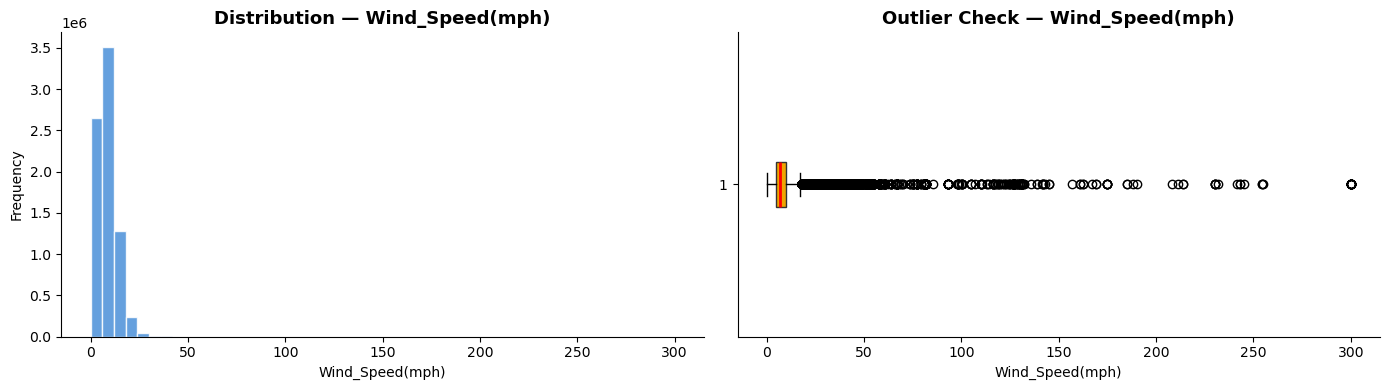

📐 Skewness : 1.6719  →  Right (positive)



In [15]:
give_Summary('Wind_Speed(mph)')

## 4.11 Precipitation(in)

| Observation | Detail |
|---|---|
| **Skewness** | Extremely right skewed |
| **Key Pattern** | ~72 lakh (7.2M) rows have Precipitation = 0 |
| **Non-zero Records** | Only ~5 lakh (0.5M) rows have Precipitation > 0 |
| **Outliers** | Present at the high end |


  Column : Precipitation(in)

📌 Statistical Summary
count    7.728394e+06
mean     6.000000e-03
std      9.330000e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.647000e+01
Name: Precipitation(in), dtype: float64



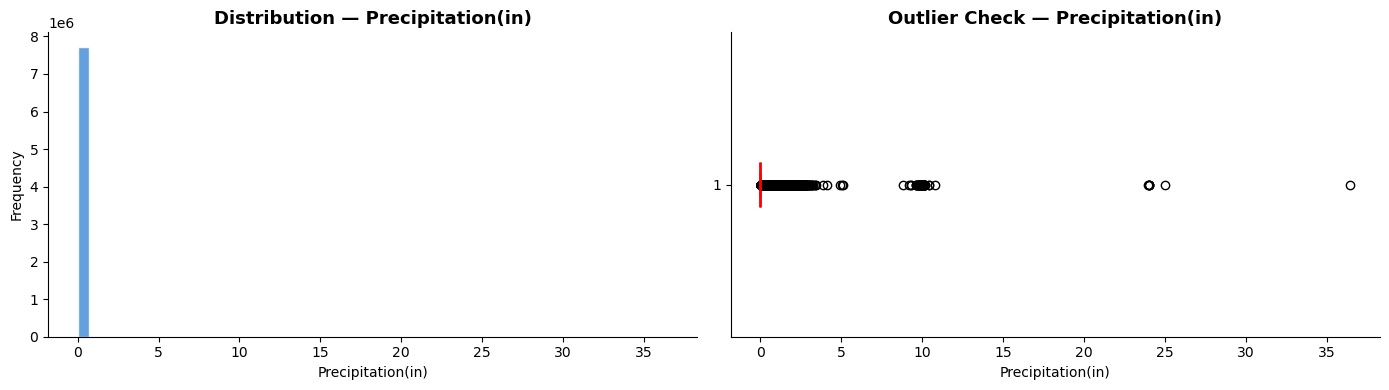

📐 Skewness : 101.5382  →  Right (positive)



In [16]:
give_Summary('Precipitation(in)')

### 🔍 Anomaly Inspection — Distance
Rows where Distance ≥ 15 miles:

In [17]:
df[df['Distance(mi)'] >= 15]

,Unnamed: 0,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,...,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Accident_Time
7629,7629,7630,Source2,2,2016-12-18 15:14:57,2016-12-18 15:44:24,37.060783,-121.057442,37.060783,-121.057442,...,False,True,False,False,False,Day,Day,Day,Day,0 days 00:29:27
37165,37165,37166,Source2,2,2016-05-03 12:20:38,2016-05-03 12:50:38,37.324512,-122.399887,37.324512,-122.399887,...,False,True,False,True,False,Day,Day,Day,Day,0 days 00:30:00
40254,40254,40255,Source2,3,2016-05-27 22:22:57,2016-05-27 23:07:57,38.007607,-121.352722,38.007607,-121.352722,...,False,False,False,False,False,Night,Night,Night,Night,0 days 00:45:00
116109,116109,116116,Source2,3,2016-12-01 04:57:37,2016-12-01 05:27:08,27.998430,-80.630264,27.998430,-80.630264,...,False,False,False,False,False,Night,Night,Night,Night,0 days 00:29:31
117113,117113,117120,Source2,3,2016-12-07 19:28:34,2016-12-07 20:12:07,27.441093,-82.459206,27.441093,-82.459206,...,False,False,False,False,False,Night,Night,Night,Night,0 days 00:43:33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7724851,7724851,7774219,Source1,2,2019-08-16 09:36:04,2019-08-16 10:04:59,43.094650,-75.742970,43.094820,-76.047420,...,False,False,False,False,False,Day,Day,Day,Day,0 days 00:28:55
7725391,7725391,7774759,Source1,3,2019-08-17 14:18:40,2019-08-17 14:46:51,42.066390,-88.254630,41.960760,-87.743450,...,False,False,False,False,False,Day,Day,Day,Day,0 days 00:28:11
7726012,7726012,7775380,Source1,2,2019-08-19 12:04:49,2019-08-19 12:34:11,46.407864,-95.280085,46.116491,-95.324917,...,False,False,False,False,False,Day,Day,Day,Day,0 days 00:29:22
7728043,7728043,7777411,Source1,4,2019-08-23 09:00:32,2019-08-23 09:29:31,27.698824,-80.895220,27.408470,-80.400380,...,False,False,False,False,False,Day,Day,Day,Day,0 days 00:28:59


### 🔍 Anomaly Inspection — Temperature
Rows where Temperature < 5°F (extreme cold outliers):

In [18]:
df[df['Temperature(F)'] < 5]

,Unnamed: 0,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,...,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Accident_Time
237,237,238,Source2,3,2016-02-18 07:47:17,2016-02-18 08:17:17,41.063995,-81.572945,41.063995,-81.572945,...,False,False,False,False,False,Day,Day,Day,Day,0 days 00:30:00
65302,65302,65304,Source2,2,2017-01-25 02:28:10,2017-01-25 03:13:58,34.247364,-117.001686,34.247364,-117.001686,...,False,False,False,False,False,Night,Night,Night,Night,0 days 00:45:48
161124,161124,161131,Source2,3,2016-12-12 08:16:02,2016-12-12 08:45:30,41.956013,-91.670692,41.956013,-91.670692,...,False,False,False,False,False,Day,Day,Day,Day,0 days 00:29:28
161126,161126,161133,Source2,3,2016-12-12 08:47:11,2016-12-12 09:16:36,41.979485,-91.671310,41.979485,-91.671310,...,False,True,False,False,False,Day,Day,Day,Day,0 days 00:29:25
161162,161162,161169,Source2,2,2016-12-13 08:16:45,2016-12-13 08:45:38,41.926865,-91.670113,41.926865,-91.670113,...,False,False,False,False,False,Day,Day,Day,Day,0 days 00:28:53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7605345,7605345,7654713,Source1,2,2017-12-30 22:47:04,2017-12-31 04:47:04,41.875590,-87.661820,41.875360,-87.652240,...,False,True,False,False,False,Night,Night,Night,Night,0 days 06:00:00
7605361,7605361,7654729,Source1,2,2017-12-30 11:22:00,2017-12-30 17:22:00,45.646670,-110.889350,45.646190,-110.880440,...,False,False,False,False,False,Day,Day,Day,Day,0 days 06:00:00
7605363,7605363,7654731,Source1,3,2017-12-30 14:51:15,2017-12-30 20:51:15,45.655734,-109.271497,45.630719,-108.928635,...,False,False,False,False,False,Day,Day,Day,Day,0 days 06:00:00
7653493,7653493,7702861,Source1,2,2019-04-03 13:21:38,2019-04-03 13:49:20,33.804596,-79.009636,33.802616,-79.007852,...,False,False,False,False,False,Day,Day,Day,Day,0 days 00:27:42


### 🔍 Anomaly Inspection — Pressure
Rows with impossible pressure values (= 0, > 35, or < 25 inHg):

In [19]:
print('Pressure == 0:')
print(df[df['Pressure(in)'] == 0].shape)
print('\nPressure > 35:')
print(df[df['Pressure(in)'] > 35].shape)
print('\nPressure < 25:')
print(df[df['Pressure(in)'] < 25].shape)

Pressure == 0:
(14, 48)

Pressure > 35:
(86, 48)

Pressure < 25:
(69950, 48)


### 🔍 Anomaly Inspection — Wind Speed
Rows with Wind Speed ≥ 253 mph (impossible values):

In [20]:
df[df['Wind_Speed(mph)'] >= 253]

,Unnamed: 0,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,...,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Accident_Time
114580,114580,114587,Source2,3,2016-06-13 18:28:43,2016-06-13 19:13:43,34.303253,-118.479774,34.303253,-118.479774,...,False,False,False,False,False,Day,Day,Day,Day,0 days 00:45:00
114588,114588,114595,Source2,3,2016-06-13 18:44:57,2016-06-13 19:29:57,34.320553,-118.495262,34.320553,-118.495262,...,False,False,False,False,False,Day,Day,Day,Day,0 days 00:45:00
114633,114633,114640,Source2,3,2016-06-13 20:06:45,2016-06-13 20:51:45,34.247803,-118.425835,34.247803,-118.425835,...,False,False,False,False,False,Night,Day,Day,Day,0 days 00:45:00
114640,114640,114647,Source2,2,2016-06-13 20:19:08,2016-06-13 21:04:08,34.266048,-118.467438,34.266048,-118.467438,...,False,False,False,False,False,Night,Day,Day,Day,0 days 00:45:00
114647,114647,114654,Source2,3,2016-06-13 20:30:47,2016-06-13 21:15:47,34.266048,-118.450768,34.266048,-118.450768,...,False,False,False,False,False,Night,Day,Day,Day,0 days 00:45:00
1739101,1739101,1748958,Source2,2,2019-10-11 15:39:46,2019-10-11 16:24:29,32.999401,-96.855743,32.999401,-96.855743,...,False,False,False,True,False,Day,Day,Day,Day,0 days 00:44:43
2638811,2638811,2648683,Source2,2,2018-08-15 12:56:31,2018-08-15 13:26:16,38.559528,-121.373108,38.559528,-121.373108,...,False,False,False,False,False,Day,Day,Day,Day,0 days 00:29:45
2638812,2638812,2648684,Source2,2,2018-08-15 13:03:11,2018-08-15 13:32:56,38.557919,-121.386116,38.557919,-121.386116,...,False,False,False,False,False,Day,Day,Day,Day,0 days 00:29:45
2791822,2791822,2801700,Source2,2,2018-05-03 08:04:38,2018-05-03 08:36:00,39.636936,-105.166359,39.636936,-105.166359,...,False,False,False,False,False,Day,Day,Day,Day,0 days 00:31:22
2791855,2791855,2801733,Source2,2,2018-05-03 07:27:00,2018-05-03 07:58:00,39.928566,-104.991646,39.928566,-104.991646,...,False,False,False,True,False,Day,Day,Day,Day,0 days 00:31:00


<a id="5"></a>
## 📝 5. Univariate Analysis — Categorical Columns

For each categorical column we examine:
- **Value counts** — frequency of each category
- **Bar chart** — volume comparison
- **Pie chart** — percentage share
- **Top-N coverage** — how much of data the top categories explain

In [21]:
def get_summary_statestical(col_name):
    vc = df[col_name].value_counts()
    n_unique = vc.count()
    top_n = 10

    print(f"{'='*60}")
    print(f"  Column   : {col_name}")
    print(f"  Unique   : {n_unique:,}")
    print(f"{'='*60}\n")

    display_vc = vc.head(top_n)
    print(f"Top {top_n} categories:\n")
    print(display_vc)
    print(f"\nTop {top_n} categories cover : {display_vc.sum():,} records ({display_vc.sum()/len(df)*100:.1f}%)\n")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Bar chart
    display_vc.plot(kind='bar', ax=axes[0], color='#4a90d9', edgecolor='white', alpha=0.9)
    axes[0].set_title(f'Top {top_n} — {col_name} (Count)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)

    # Pie chart
    display_vc.plot(kind='pie', ax=axes[1], autopct='%.1f%%',
                    startangle=140, colors=sns.color_palette('Blues_r', top_n))
    axes[1].set_title(f'Top {top_n} — {col_name} (% Share)', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

## 5.1 Source
Where were accidents reported from? Almost all data originates from 2 sources.

  Column   : Source
  Unique   : 3

Top 10 categories:

Source
Source1    4325632
Source2    3305373
Source3      97389
Name: count, dtype: int64

Top 10 categories cover : 7,728,394 records (100.0%)



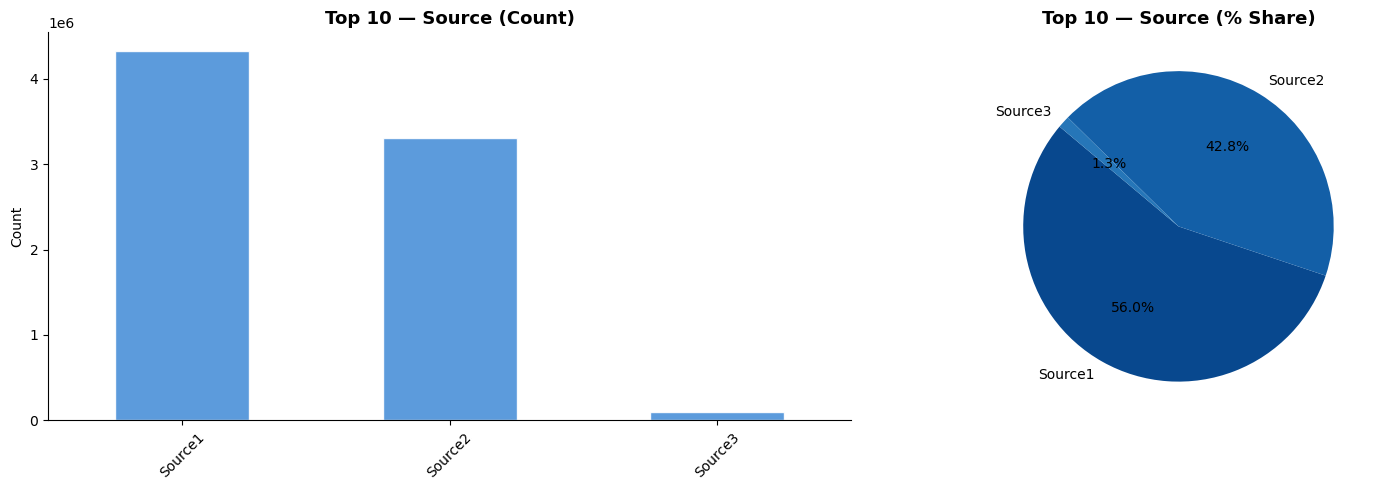

In [22]:
get_summary_statestical('Source')

## 5.2 Street
Street-level accident distribution — over 336,000 unique streets in the dataset.

  Column   : Street
  Unique   : 336,307

Top 10 categories:

Street
I-95 N     78430
I-95 S     74528
I-5 N      71968
I-10 E     55572
I-10 W     53725
I-5 S      51781
I-80 W     39662
I-80 E     36113
I-405 N    32364
I-75 N     28166
Name: count, dtype: int64

Top 10 categories cover : 522,309 records (6.8%)



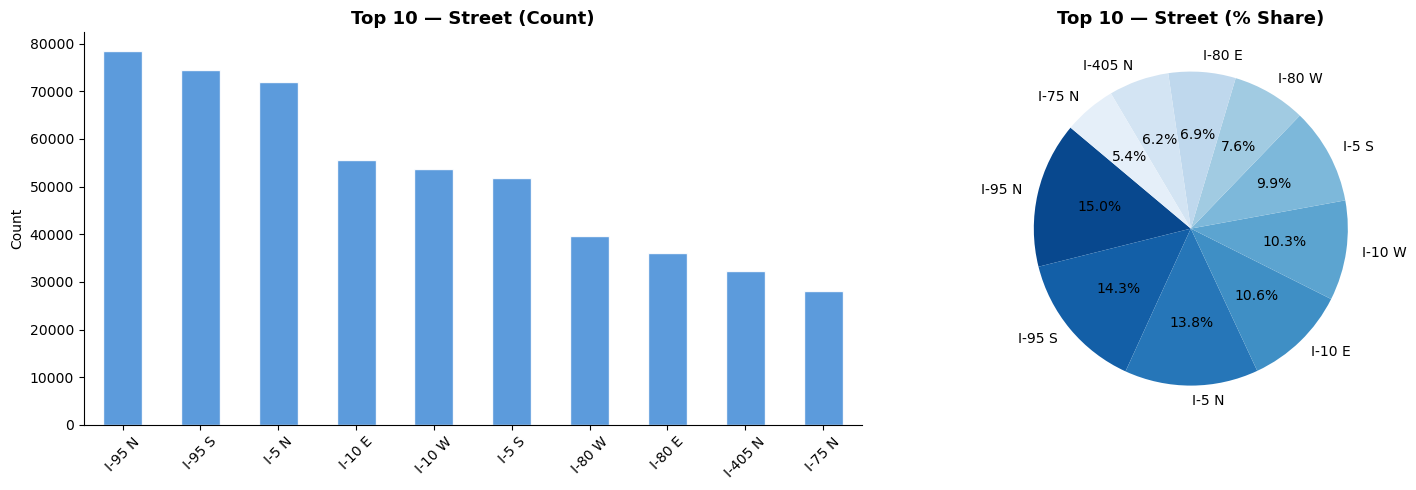

In [23]:
get_summary_statestical('Street')

## 5.3 County
County-wise accident distribution.

  Column   : County
  Unique   : 1,871

Top 10 categories:

County
Los Angeles       526851
Miami-Dade        251601
Orange            241275
Harris            181196
Dallas            157024
Mecklenburg       147265
Montgomery        136788
Wake              117890
San Bernardino    109631
Travis            107881
Name: count, dtype: int64

Top 10 categories cover : 1,977,402 records (25.6%)



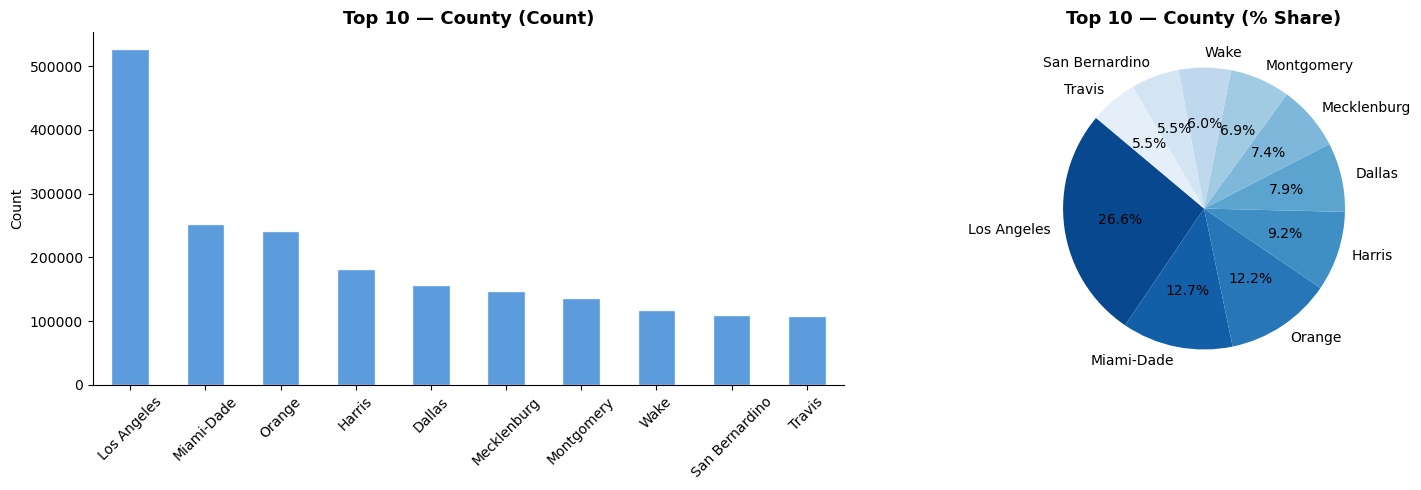

In [24]:
get_summary_statestical('County')

## 5.4 State
State-wise accident distribution — California dominates significantly.

  Column   : State
  Unique   : 49

Top 10 categories:

State
California        1741433
Florida            880192
Texas              582837
South Carolina     382557
New York           347960
North Carolina     338199
Virginia           303301
Pennsylvania       296620
Minnesota          192084
Oregon             179660
Name: count, dtype: int64

Top 10 categories cover : 5,244,843 records (67.9%)



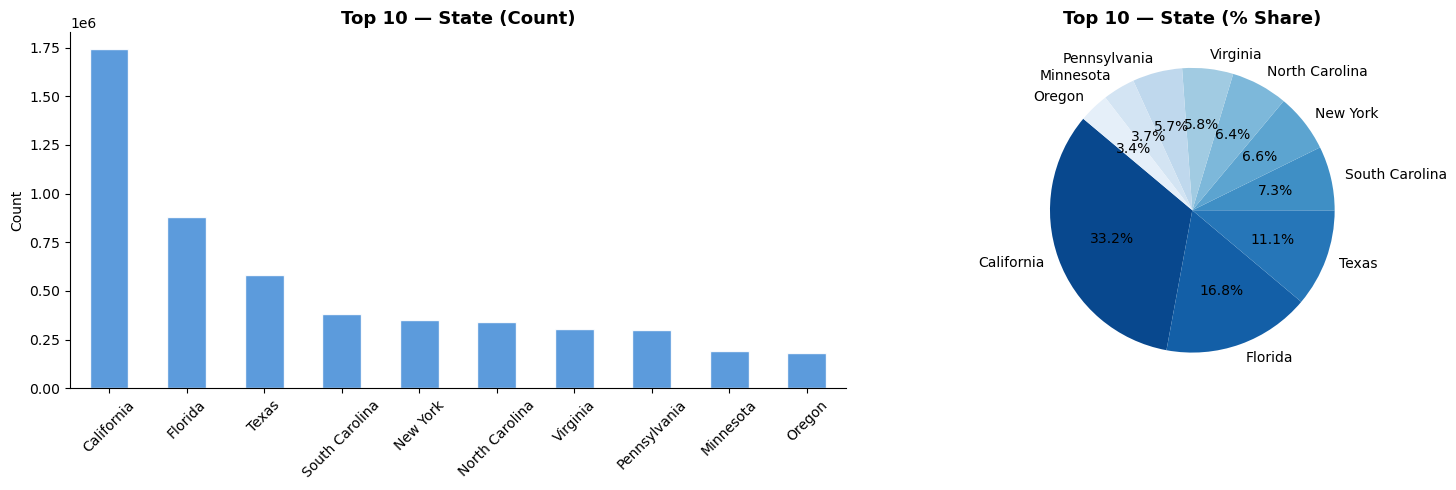

In [25]:
get_summary_statestical('State')

## 5.5 Timezone
Timezone of the accident location — proxy for geographic region.

  Column   : Timezone
  Unique   : 4

Top 10 categories:

Timezone
Eastern     3580454
Pacific     2065336
Central     1650016
Mountain     432588
Name: count, dtype: int64

Top 10 categories cover : 7,728,394 records (100.0%)



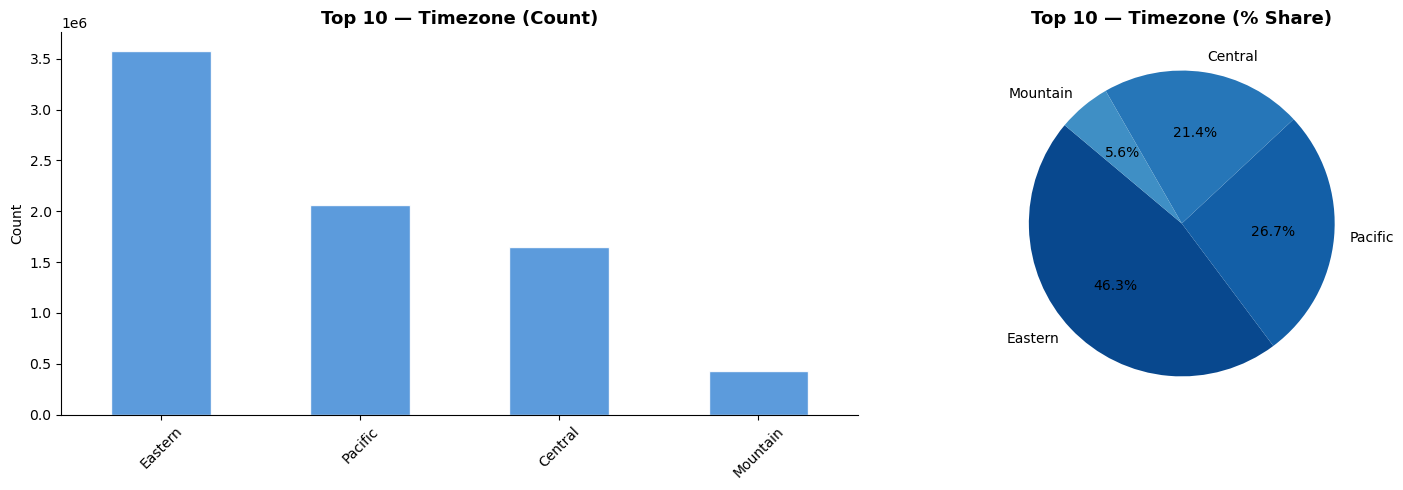

In [26]:
get_summary_statestical('Timezone')

## 5.6 Severity
Accident severity scale: 1 (minor) → 4 (severe).

  Column   : Severity
  Unique   : 4

Top 10 categories:

Severity
2    6156981
3    1299337
4     204710
1      67366
Name: count, dtype: int64

Top 10 categories cover : 7,728,394 records (100.0%)



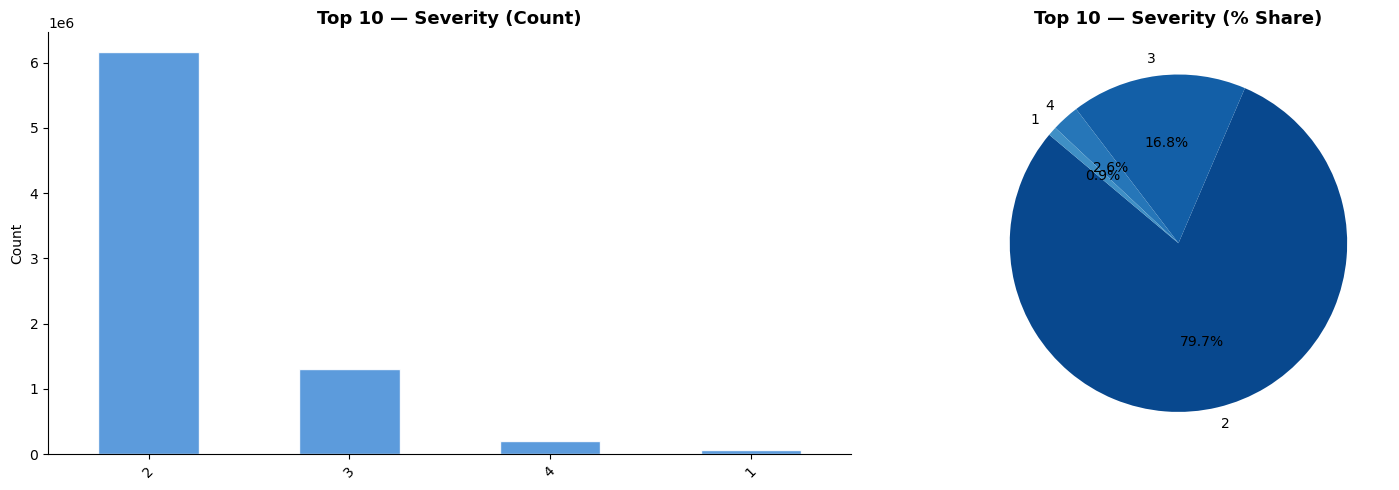

In [27]:
get_summary_statestical('Severity')

## 5.7 Weather Condition
Atmospheric conditions at the time of accident.

  Column   : Weather_Condition
  Unique   : 144

Top 10 categories:

Weather_Condition
Fair                2734261
Mostly Cloudy       1016195
Cloudy               817082
Clear                808743
Partly Cloudy        698972
Overcast             382866
Light Rain           352957
Scattered Clouds     204829
Light Snow           128680
Fog                   99238
Name: count, dtype: int64

Top 10 categories cover : 7,243,823 records (93.7%)



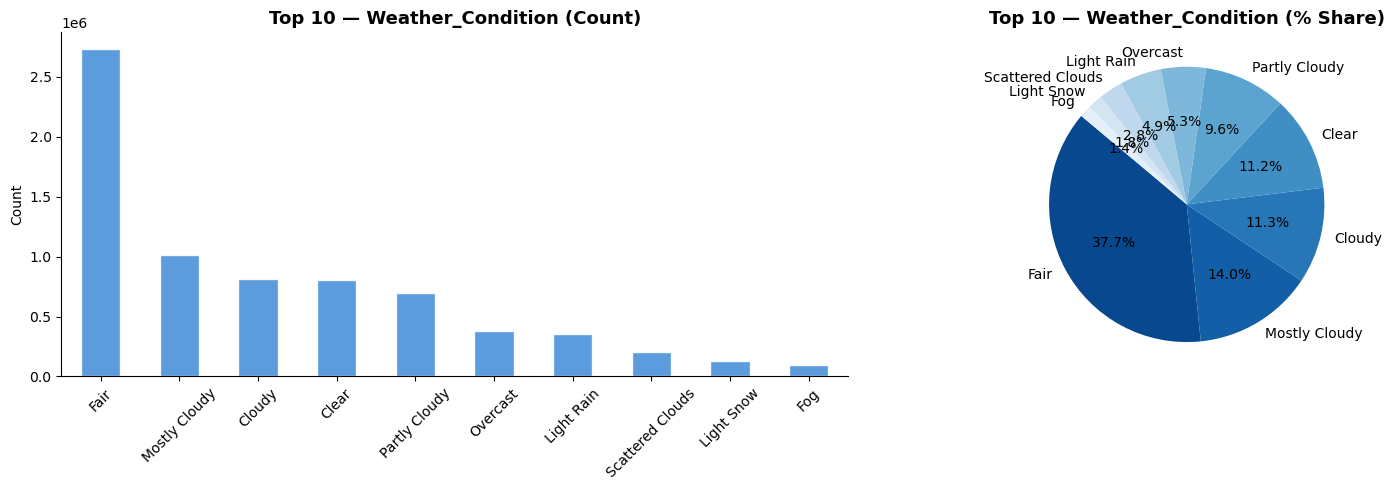

In [28]:
get_summary_statestical('Weather_Condition')

## 5.8 Wind Direction
Prevailing wind direction during the accident.

  Column   : Wind_Direction
  Unique   : 6

Top 10 categories:

Wind_Direction
CALM        1505387
South        597364
West         548664
North        460536
East         382459
Varaible     250566
Name: count, dtype: int64

Top 10 categories cover : 3,744,976 records (48.5%)



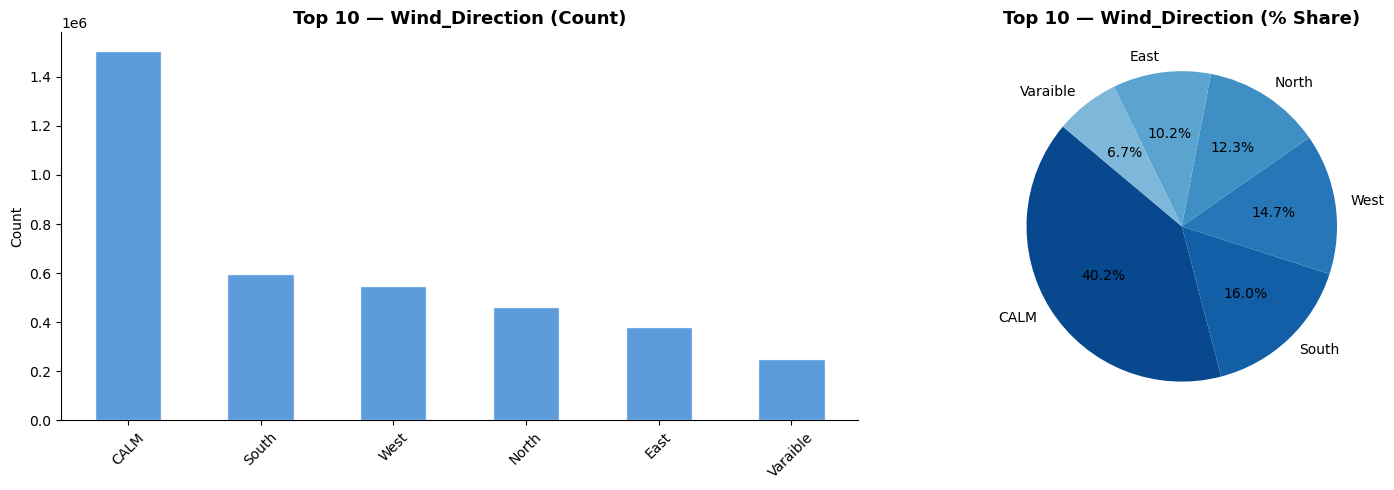

In [29]:
get_summary_statestical('Wind_Direction')

## 5.9 Sunrise / Sunset (Day vs Night)
Whether accident occurred during day or night.

  Column   : Sunrise_Sunset
  Unique   : 2

Top 10 categories:

Sunrise_Sunset
Day      5357799
Night    2370595
Name: count, dtype: int64

Top 10 categories cover : 7,728,394 records (100.0%)



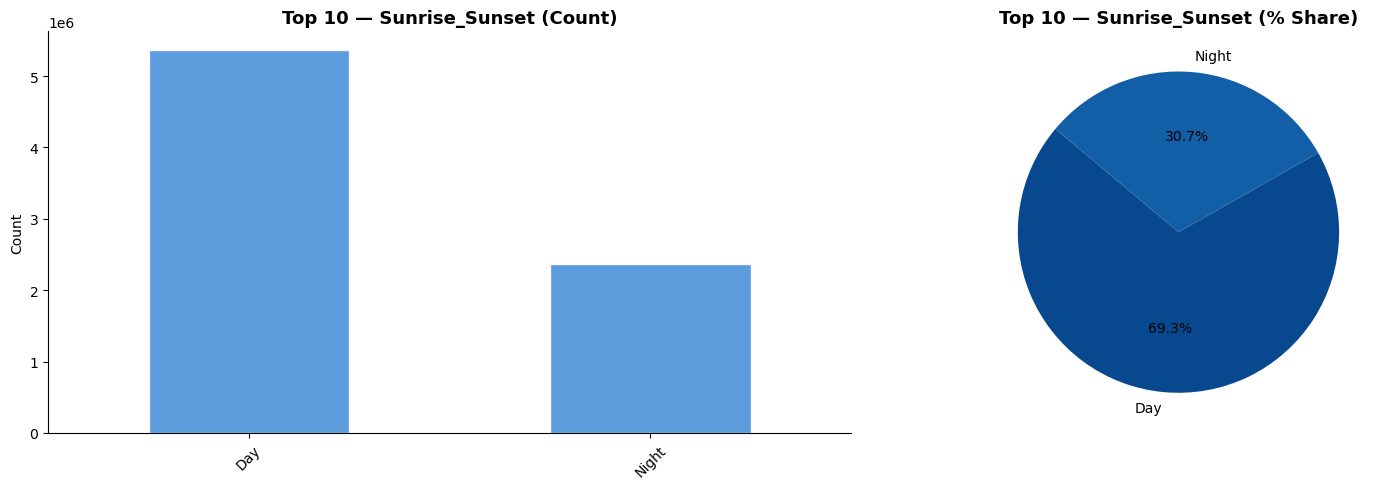

In [30]:
get_summary_statestical('Sunrise_Sunset')

## 5.10 Civil Twilight
Light condition category based on sun position.

  Column   : Civil_Twilight
  Unique   : 2

Top 10 categories:

Civil_Twilight
Day      5718865
Night    2009529
Name: count, dtype: int64

Top 10 categories cover : 7,728,394 records (100.0%)



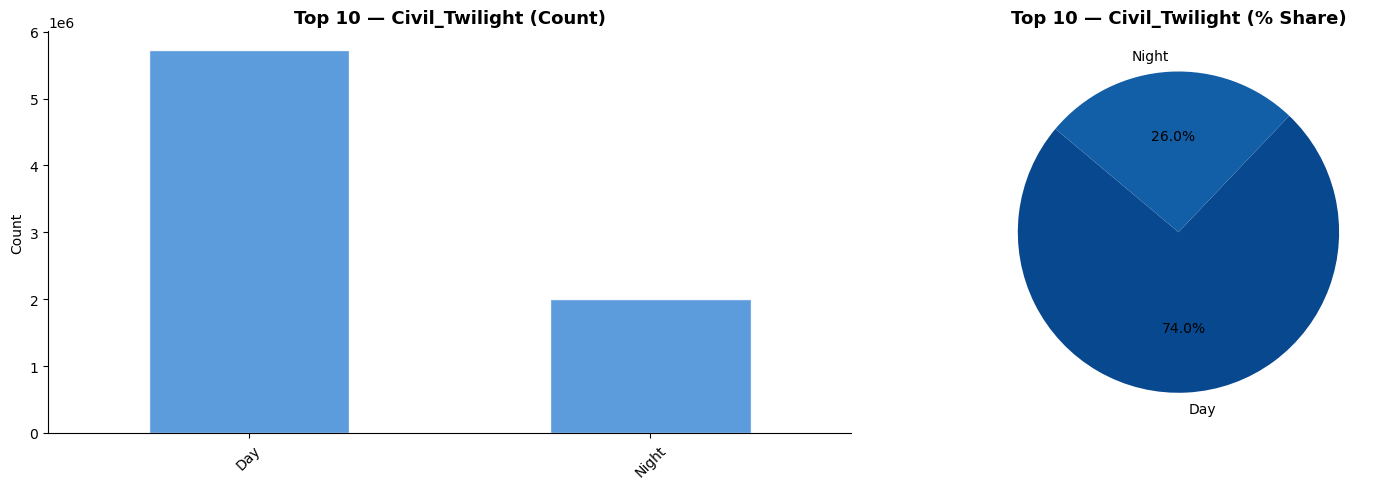

In [31]:
get_summary_statestical('Civil_Twilight')

### 🔍 Deep Dive — Street
Top 10,000 streets by accident count:

In [32]:
top_streets = df['Street'].value_counts()
print(f"Total unique streets : {top_streets.nunique():,}")
print(f"Top 10,000 streets cover : {top_streets.head(10000).sum():,} accidents "
      f"({top_streets.head(10000).sum()/len(df)*100:.1f}%)")

Total unique streets : 1,609
Top 10,000 streets cover : 5,580,096 accidents (72.2%)


### 🔍 Deep Dive — County
Top 200 counties by accident count:

In [33]:
top_counties = df['County'].value_counts()
print(f"Top 200 counties cover : {top_counties.head(200).sum():,} accidents "
      f"({top_counties.head(200).sum()/len(df)*100:.1f}%)")

Top 200 counties cover : 6,531,547 accidents (84.5%)


<a id="6"></a>
## 🔎 6. Key Findings — Univariate Analysis

> Summary of the most important observations from individual column analysis.

| # | Finding |
|---|---------|
| 1 | **Source** — ~99% of data comes from just 2 sources (Source1 & Source2) |
| 2 | **Street** — 336,307 unique streets; top 10,000 streets account for >50% of all accidents |
| 3 | **Street pattern** — Streets starting with "I" (Interstates) have the highest accident counts |
| 4 | **City** — Miami has highest accidents (~15%), followed by Los Angeles, Charlotte, Dallas |
| 5 | **County** — Los Angeles County alone accounts for ~27% of all accidents |
| 6 | **County coverage** — Top 200 counties hold ~65 lakh (6.5M) accidents |
| 7 | **State** — California contributes ~33% of total accidents |
| 8 | **State coverage** — Top 10 states account for ~52 lakh (5.2M) accidents |
| 9 | **Timezone** — Eastern timezone leads with ~47% of accidents |
| 10 | **Timezone order** — Eastern > Pacific > Central > Mountain |
| 11 | **Severity** — ~80% of accidents are mild (Severity = 2) |
| 12 | **Weather** — 38% of accidents occur in Fair weather; 76% in clear conditions overall |
| 13 | **Wind** — 29% of the time wind is Calm (15 lakh records); top 10 wind categories = ~53 lakh accidents |
| 14 | **Day/Night** — ~70% of accidents happen during daytime |
| 15 | **Pressure** — 14 rows have Pressure = 0 (data quality issue) |
| 16 | **Wind Speed** — 21 rows exceed 253 mph (impossible values, data quality issue) |

<a id="7"></a>
## 📈 7. Bivariate Analysis

Understanding **relationships between two variables** — how does one feature influence another?

We explore:
- **Categorical × Numerical** — group-wise distributions
- **Categorical × Categorical** — crosstab heatmaps
- **Numerical × Numerical** — correlations

### 7.1 Weather Condition × Severity
**Question:** Does weather type influence accident severity?

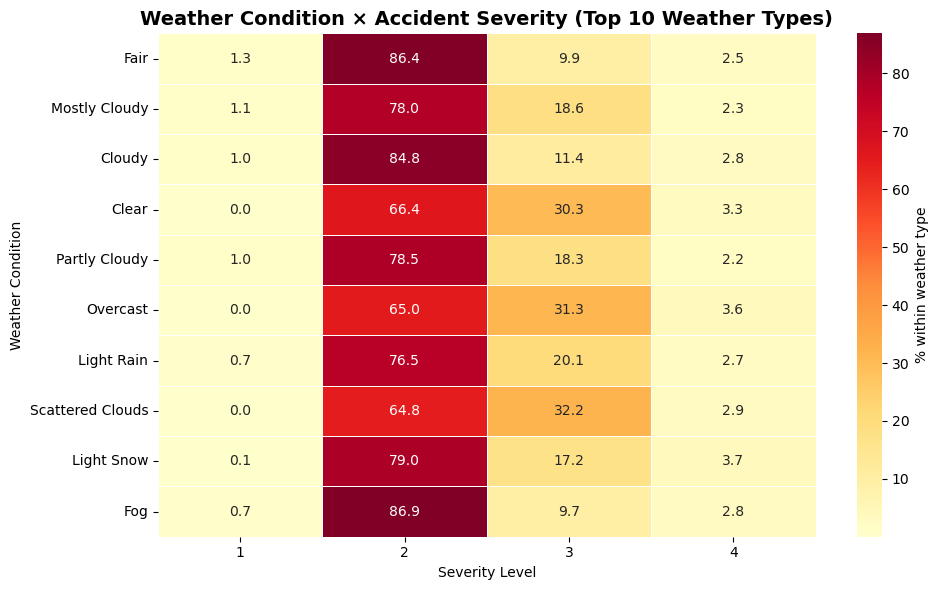


📌 Insight: Most weather types are dominated by Severity=2 (mild).
   Severe conditions like Snow and Freezing Drizzle show a higher share of Severity 3 & 4.


In [34]:
df_biv = pd.read_csv('Clened_Dataset.csv', low_memory=False)

ct = pd.crosstab(df_biv['Weather_Condition'], df_biv['Severity'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
top10_weather = ct.sum(axis=1).nlargest(10).index
ct_pct_top = ct_pct.loc[top10_weather]

plt.figure(figsize=(10, 6))
sns.heatmap(ct_pct_top, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.4, cbar_kws={'label': '% within weather type'})
plt.title('Weather Condition × Accident Severity (Top 10 Weather Types)', fontsize=14, fontweight='bold')
plt.xlabel('Severity Level')
plt.ylabel('Weather Condition')
plt.tight_layout()
plt.show()

print("\n📌 Insight: Most weather types are dominated by Severity=2 (mild).")
print("   Severe conditions like Snow and Freezing Drizzle show a higher share of Severity 3 & 4.")

### 7.2 State × Severity
**Question:** Which states have proportionally more severe accidents?

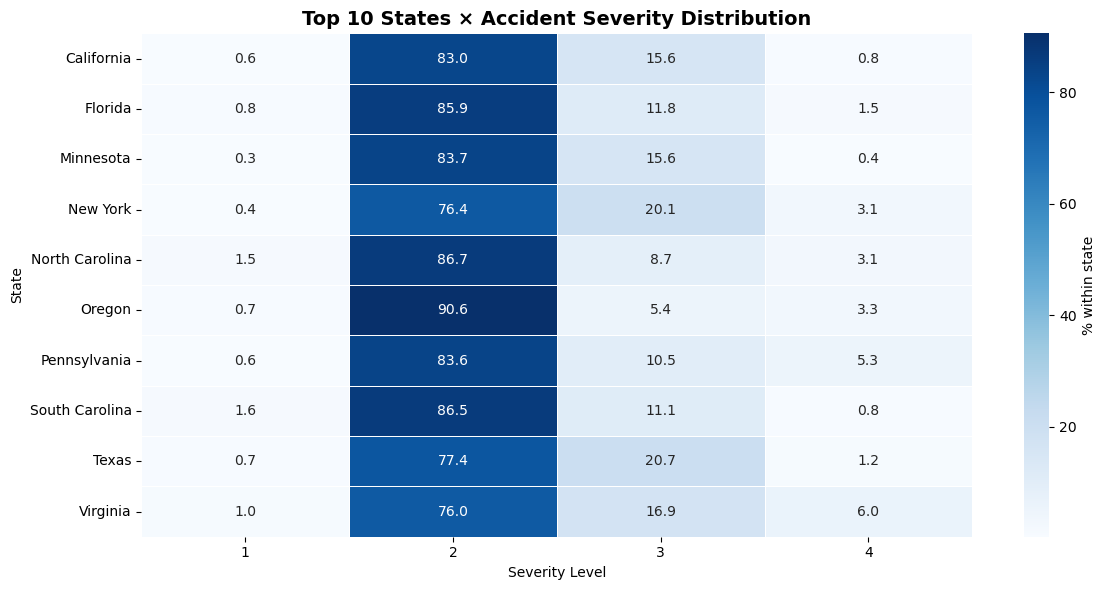


📌 Insight: All top states are dominated by Severity=2.
   Some states show higher proportion of Severity=3 — worth flagging for road safety policy.


In [35]:
top10_states = df_biv['State'].value_counts().head(10).index
df_top_states = df_biv[df_biv['State'].isin(top10_states)]

ct_state = pd.crosstab(df_top_states['State'], df_top_states['Severity'])
ct_state_pct = ct_state.div(ct_state.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 6))
sns.heatmap(ct_state_pct, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.4, cbar_kws={'label': '% within state'})
plt.title('Top 10 States × Accident Severity Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Severity Level')
plt.ylabel('State')
plt.tight_layout()
plt.show()

print("\n📌 Insight: All top states are dominated by Severity=2.")
print("   Some states show higher proportion of Severity=3 — worth flagging for road safety policy.")

### 7.3 Timezone × Severity
**Question:** Does accident timezone affect how severe accidents tend to be?

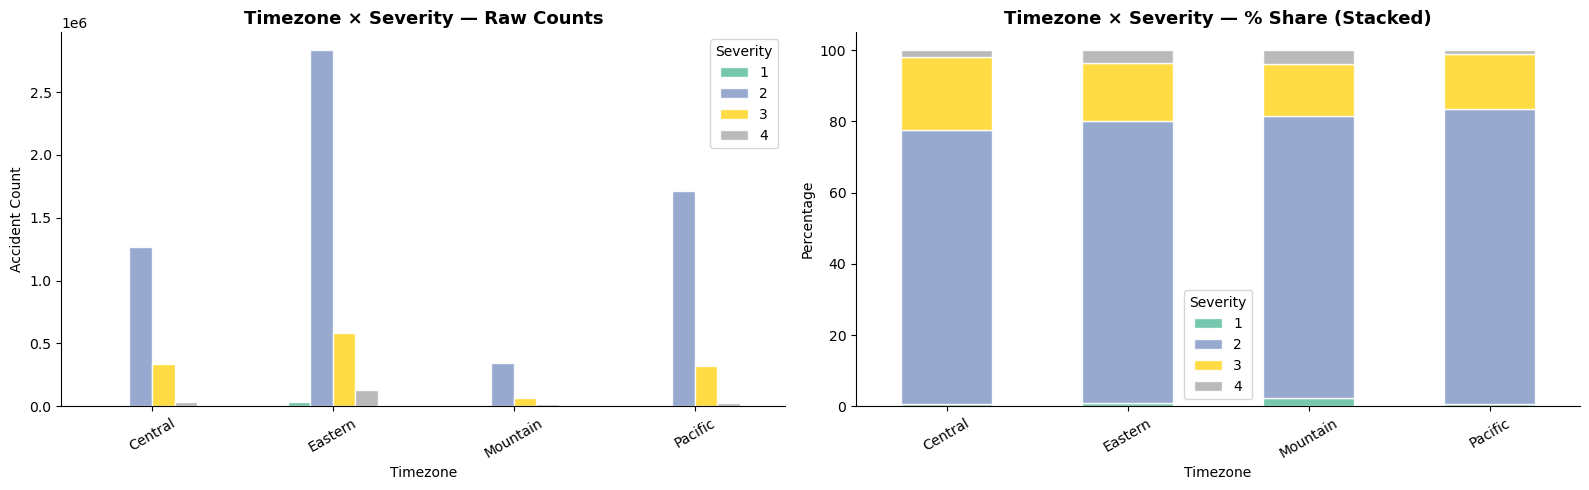


📌 Insight: Eastern timezone has the highest accident volume.
   Severity distribution is consistent across timezones — no strong timezone-severity pattern.


In [36]:
ct_tz = pd.crosstab(df_biv['Timezone'], df_biv['Severity'])
ct_tz_pct = ct_tz.div(ct_tz.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ct_tz.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white', alpha=0.9)
axes[0].set_title('Timezone × Severity — Raw Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Timezone')
axes[0].set_ylabel('Accident Count')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Severity')

ct_tz_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2', edgecolor='white', alpha=0.9)
axes[1].set_title('Timezone × Severity — % Share (Stacked)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Timezone')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Severity')

plt.tight_layout()
plt.show()

print("\n📌 Insight: Eastern timezone has the highest accident volume.")
print("   Severity distribution is consistent across timezones — no strong timezone-severity pattern.")

### 7.4 Day vs Night × Severity
**Question:** Are nighttime accidents more severe than daytime accidents?

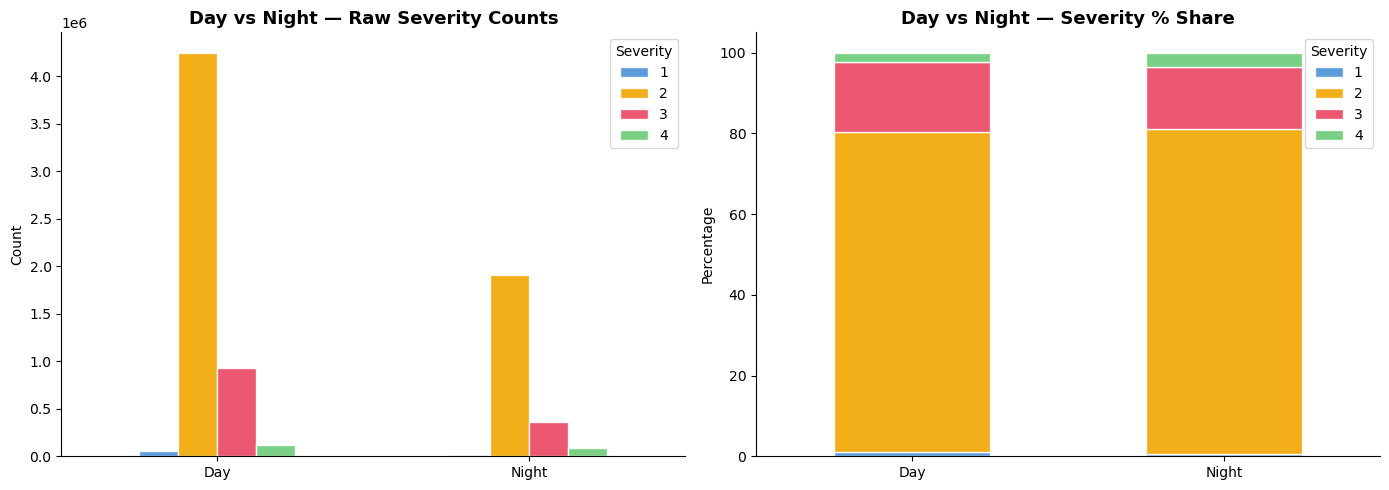


📌 Insight: Night accidents show a slightly higher proportion of Severity 3 & 4.
   Night driving is riskier — visibility and driver alertness factors likely contribute.


In [37]:
ct_sun = pd.crosstab(df_biv['Sunrise_Sunset'], df_biv['Severity'])
ct_sun_pct = ct_sun.div(ct_sun.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4a90d9', '#f0a500', '#e94560', '#6bcb77']

ct_sun.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', alpha=0.9)
axes[0].set_title('Day vs Night — Raw Severity Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Severity')

ct_sun_pct.plot(kind='bar', stacked=True, ax=axes[1], color=colors, edgecolor='white', alpha=0.9)
axes[1].set_title('Day vs Night — Severity % Share', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Severity')

plt.tight_layout()
plt.show()

print("\n📌 Insight: Night accidents show a slightly higher proportion of Severity 3 & 4.")
print("   Night driving is riskier — visibility and driver alertness factors likely contribute.")

### 7.5 Temperature Distribution by Severity
**Question:** Does temperature at the time of accident relate to its severity?

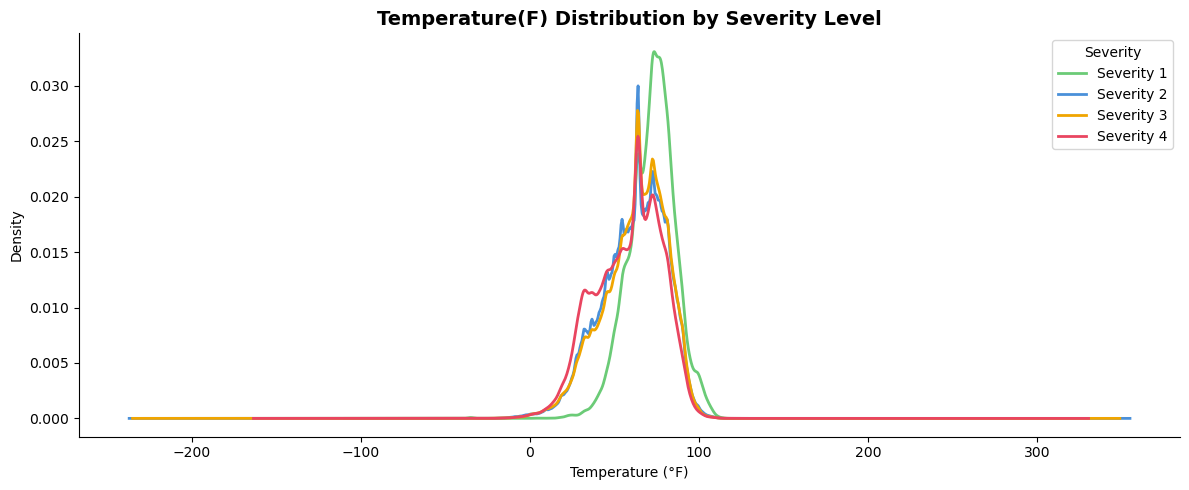


📌 Insight: All severity levels share similar temperature distributions.
   Severity 3 & 4 show a marginally wider spread toward extreme cold temperatures.


In [38]:
plt.figure(figsize=(12, 5))
severity_colors = {1: '#6bcb77', 2: '#4a90d9', 3: '#f0a500', 4: '#e94560'}
for sev in sorted(df_biv['Severity'].dropna().unique()):
    subset = df_biv[df_biv['Severity'] == sev]['Temperature(F)'].dropna()
    subset.plot(kind='kde', label=f'Severity {int(sev)}',
                color=severity_colors.get(sev, 'gray'), linewidth=2)

plt.title('Temperature(F) Distribution by Severity Level', fontsize=14, fontweight='bold')
plt.xlabel('Temperature (°F)')
plt.ylabel('Density')
plt.legend(title='Severity')
plt.tight_layout()
plt.show()

print("\n📌 Insight: All severity levels share similar temperature distributions.")
print("   Severity 3 & 4 show a marginally wider spread toward extreme cold temperatures.")

### 7.6 Humidity Distribution by Severity
**Question:** Do high humidity conditions lead to more severe accidents?

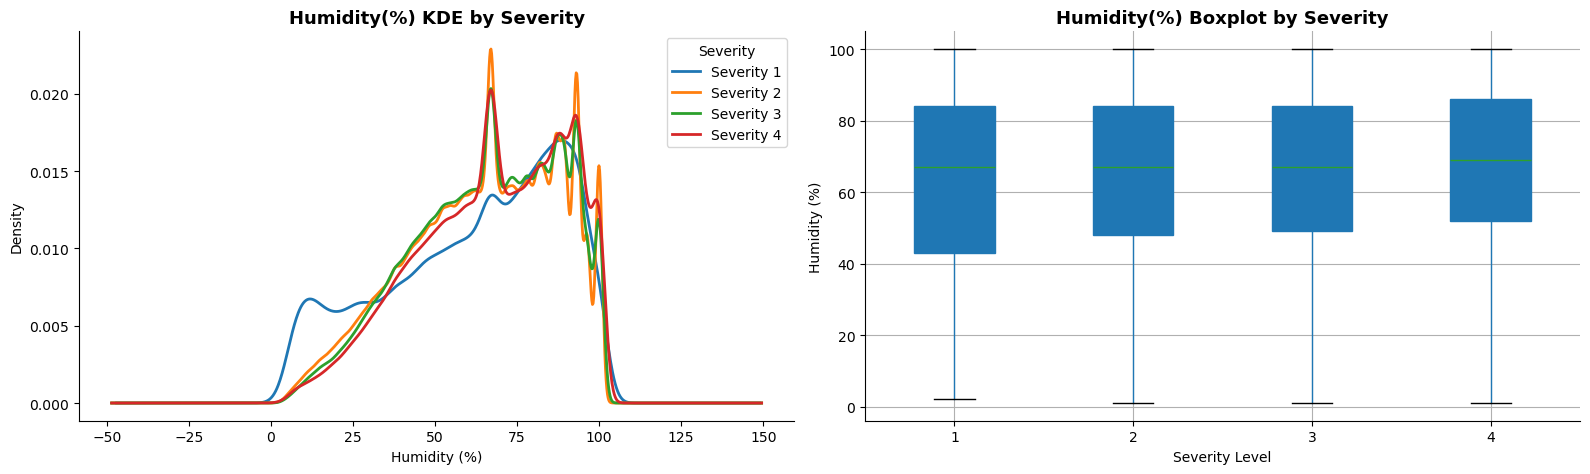


📌 Insight: Higher severity accidents (3 & 4) tend to occur at higher humidity levels.
   Wet/foggy conditions likely increase accident severity.


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for sev in sorted(df_biv['Severity'].dropna().unique()):
    subset = df_biv[df_biv['Severity'] == sev]['Humidity(%)'].dropna()
    subset.plot(kind='kde', ax=axes[0], label=f'Severity {int(sev)}', linewidth=2)
axes[0].set_title('Humidity(%) KDE by Severity', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Humidity (%)')
axes[0].legend(title='Severity')

df_biv.boxplot(column='Humidity(%)', by='Severity', ax=axes[1],
               patch_artist=True, notch=False)
axes[1].set_title('Humidity(%) Boxplot by Severity', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Severity Level')
axes[1].set_ylabel('Humidity (%)')
plt.suptitle('')
plt.tight_layout()
plt.show()

print("\n📌 Insight: Higher severity accidents (3 & 4) tend to occur at higher humidity levels.")
print("   Wet/foggy conditions likely increase accident severity.")

### 7.7 Distance(mi) by Severity
**Question:** Do more severe accidents span longer distances?

Distance Statistics by Severity:

           mean  median    std
Severity                      
1         0.115   0.000  0.759
2         0.565   0.068  1.567
3         0.424   0.000  2.241
4         1.496   0.473  3.489


<Figure size 1000x500 with 0 Axes>

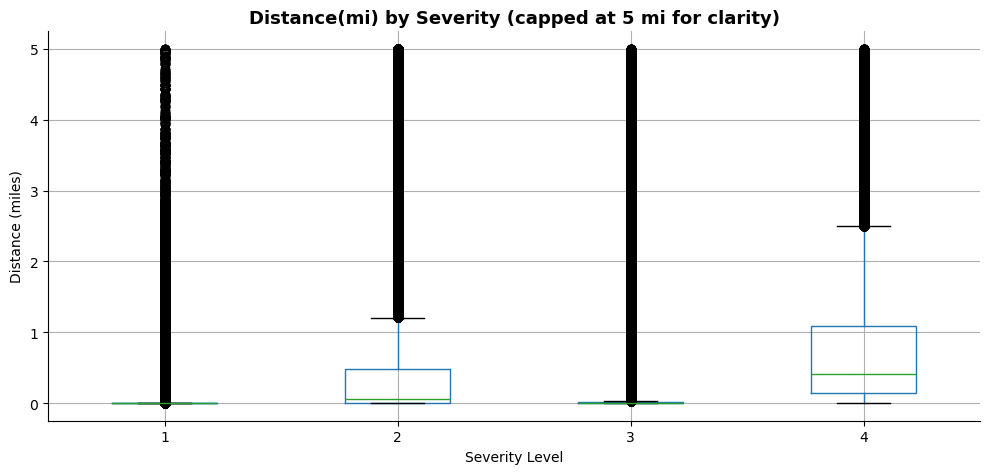


📌 Insight: Higher severity accidents tend to have slightly longer impact distances.
   Most accidents are near 0 miles regardless of severity.


In [40]:
dist_sev = df_biv.groupby('Severity')['Distance(mi)'].agg(['mean', 'median', 'std']).round(3)
print("Distance Statistics by Severity:\n")
print(dist_sev)

plt.figure(figsize=(10, 5))
df_biv[df_biv['Distance(mi)'] < 5].boxplot(column='Distance(mi)', by='Severity')
plt.title('Distance(mi) by Severity (capped at 5 mi for clarity)', fontsize=13, fontweight='bold')
plt.suptitle('')
plt.xlabel('Severity Level')
plt.ylabel('Distance (miles)')
plt.tight_layout()
plt.show()

print("\n📌 Insight: Higher severity accidents tend to have slightly longer impact distances.")
print("   Most accidents are near 0 miles regardless of severity.")

### 7.8 Top Streets — Accident Hotspot Analysis
**Question:** Which streets are true accident hotspots?

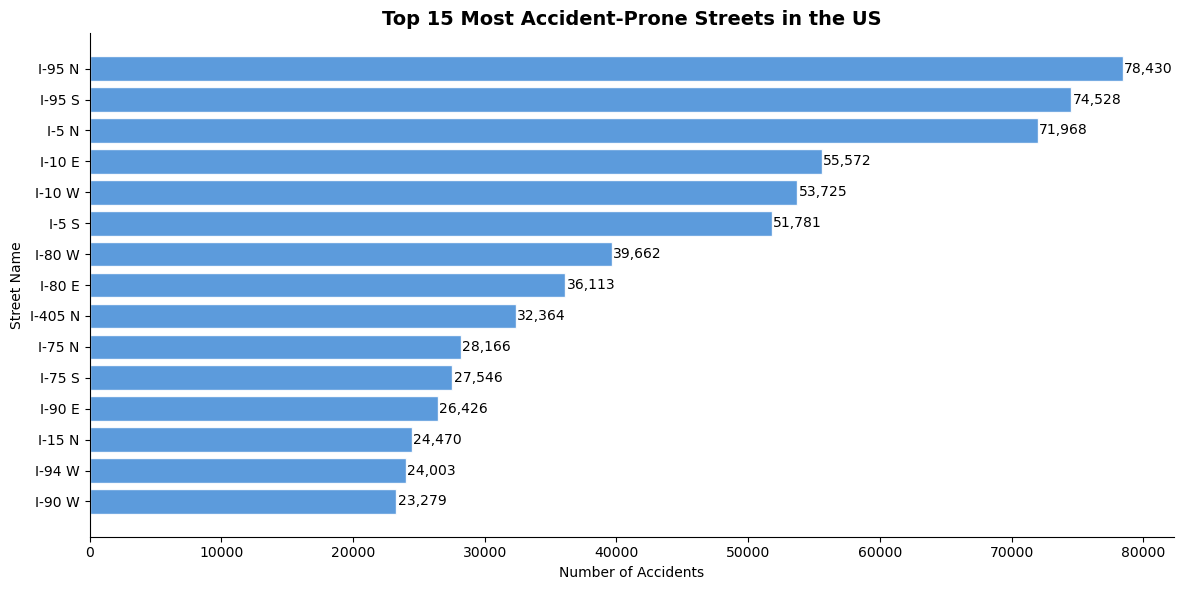


📌 Insight: Interstate highways dominate the top accident-prone streets.
   I-95, I-5, I-75 are consistently high — high traffic volume + speed are primary factors.


In [41]:
top15_streets = df_biv['Street'].value_counts().head(15).reset_index()
top15_streets.columns = ['Street', 'Accident_Count']

plt.figure(figsize=(12, 6))
bars = plt.barh(top15_streets['Street'][::-1], top15_streets['Accident_Count'][::-1],
                color='#4a90d9', edgecolor='white', alpha=0.9)
plt.title('Top 15 Most Accident-Prone Streets in the US', fontsize=14, fontweight='bold')
plt.xlabel('Number of Accidents')
plt.ylabel('Street Name')
for bar, val in zip(bars, top15_streets['Accident_Count'][::-1]):
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print("\n📌 Insight: Interstate highways dominate the top accident-prone streets.")
print("   I-95, I-5, I-75 are consistently high — high traffic volume + speed are primary factors.")

### 7.9 Correlation Heatmap — Numerical Columns
**Question:** Which numerical features are correlated with each other?

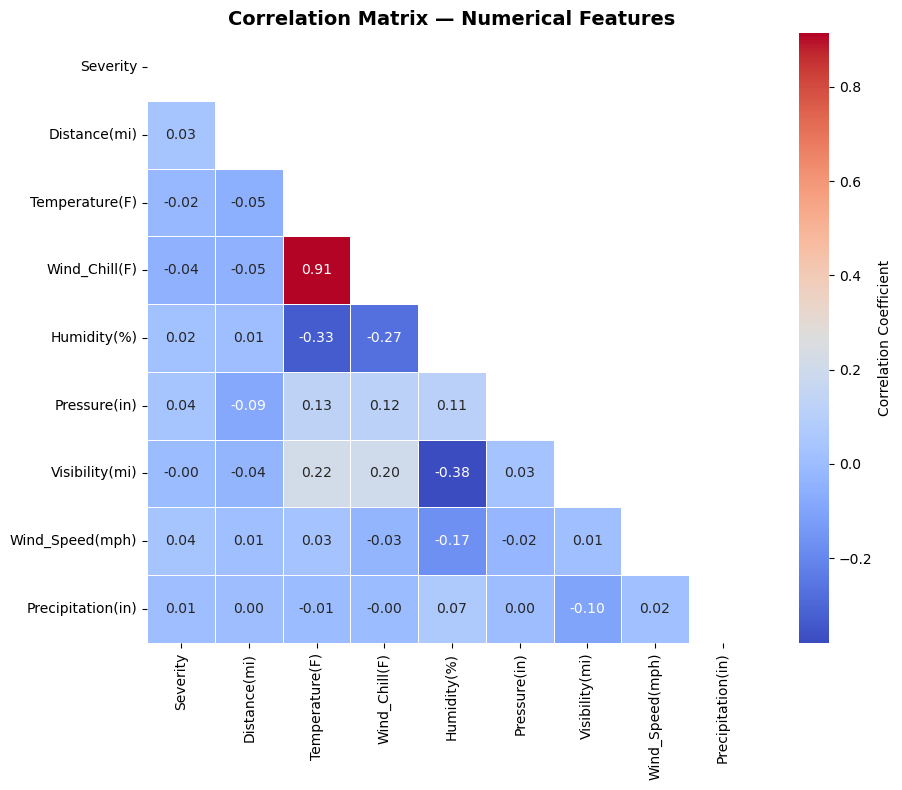


📌 Key correlations:
   - Temperature(F) & Wind_Chill(F) : Strong positive (expected — they measure related phenomena)
   - Humidity(%) & Visibility(mi)   : Moderate negative (higher humidity → lower visibility)
   - Severity & other features      : Weak correlations (severity is influenced by many factors)


In [42]:
num_cols = ['Severity', 'Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)',
             'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

corr_matrix = df_biv[num_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Key correlations:")
print("   - Temperature(F) & Wind_Chill(F) : Strong positive (expected — they measure related phenomena)")
print("   - Humidity(%) & Visibility(mi)   : Moderate negative (higher humidity → lower visibility)")
print("   - Severity & other features      : Weak correlations (severity is influenced by many factors)")

<a id="8"></a>
## 💡 8. Final Insights Summary

### 🏆 Top Takeaways from the Full EDA

| Category | Key Insight |
|---|---|
| **Geography** | California (33%) and Los Angeles County (27%) are extreme accident hotspots |
| **Location** | Interstate highways (I-prefix streets) dominate accident counts |
| **Severity** | 80% of all accidents are Severity=2 (mild) — severe accidents are rare |
| **Weather** | 76% of accidents happen in clear weather — clear ≠ safe |
| **Time of Day** | 70% of accidents happen during daytime (higher traffic volume) |
| **Night risk** | Nighttime accidents show slightly higher Severity 3 & 4 proportion |
| **Humidity** | Higher severity accidents correlate with higher humidity — wet conditions matter |
| **Temperature** | Extreme cold increases outlier risk but not dramatically changes severity |
| **Wind** | Calm wind (29% of cases) has most accidents — not wind but traffic volume drives accidents |
| **Data Quality** | Wind speed > 253 mph (21 rows), Pressure = 0 (14 rows) — clear data entry errors |

---

### 🔮 What to Explore Next
- **Time series analysis** — accident trends by hour, weekday, month, year
- **Geospatial mapping** — plot accident hotspots on US map using lat/lng
- **Feature engineering** — create response time column, accident duration, time-of-day bins
- **ML modelling** — predict Severity given weather, location, and time features

<div style='background: linear-gradient(135deg, #0f3460 0%, #16213e 100%); padding: 30px; border-radius: 12px; margin-top: 30px;'>
    <h1 style='color: #e94560; font-size: 2em; margin:0;'>📝 Practice Questions & Answers</h1>
    <p style='color: #a8b2d8; font-size: 1em; margin-top: 10px;'>20 Questions — Easy to Hard | Pandas & NumPy</p>
</div>

### Q1. What is the shape of the dataset? How many rows and columns?

In [43]:
# Q1 — Shape of the dataset
print(f"Shape : {df.shape}")
print(f"Rows  : {df.shape[0]:,}")
print(f"Cols  : {df.shape[1]}")

Shape : (7728394, 48)
Rows  : 7,728,394
Cols  : 48


### Q2. What are the column names and their data types?

In [44]:
# Q2 — Column names and data types
df.dtypes

Unnamed: 0                 int64
ID                         int64
Source                    object
Severity                   int64
Start_Time                object
End_Time                  object
Start_Lat                float64
Start_Lng                float64
End_Lat                  float64
End_Lng                  float64
Distance(mi)             float64
Description               object
Street                    object
City                      object
County                    object
State                     object
Zipcode                    int64
Country                   object
Timezone                  object
Airport_Code              object
Weather_Timestamp         object
Temperature(F)             int64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)               int64
Visibility(mi)             int64
Wind_Direction            object
Wind_Speed(mph)          float64
Precipitation(in)        float64
Weather_Condition         object
Amenity   

### Q3. How many null/missing values are there in each column?

In [45]:
# Q3 — Null values per column
null_counts = df.isnull().sum()
null_counts[null_counts > 0]

Wind_Direction    3983418
dtype: int64

### Q4. What is the date range of the accidents in this dataset?

In [46]:
# Q4 — Date range
df['Start_Time'] = pd.to_datetime(df['Start_Time'])
print(f"First accident : {df['Start_Time'].min()}")
print(f"Last  accident : {df['Start_Time'].max()}")

First accident : 2016-01-14 20:18:33
Last  accident : 2023-03-31 23:30:00


### Q5. How many unique states are covered in the dataset?

In [47]:
# Q5 — Unique states
print(f"Unique states : {df['State'].nunique()}")

Unique states : 49


### Q6. What are the top 5 cities with the most accidents?

In [48]:
# Q6 — Top 5 cities
df['City'].value_counts().head(5)

City
Miami          186917
Houston        169609
Los Angeles    156491
Charlotte      138652
Dallas         130939
Name: count, dtype: int64

### Q7. What is the distribution of accident severity levels? (value counts + %)

In [49]:
# Q7 — Severity distribution
vc = df['Severity'].value_counts().sort_index()
pct = (vc / len(df) * 100).round(2)
result = pd.DataFrame({'Count': vc, 'Percentage(%)': pct})
result

,Count,Percentage(%)
Severity,,
1,67366,0.87
2,6156981,79.67
3,1299337,16.81
4,204710,2.65


### Q8. Which hours of the day see the highest number of accidents?

In [50]:
# Q8 — Accidents by hour
df['Start_Time'] = pd.to_datetime(df['Start_Time'])
hourly = df['Start_Time'].dt.hour.value_counts().sort_index()
print(hourly)
print(f"\nPeak hour : {hourly.idxmax()}:00 with {hourly.max():,} accidents")

Start_Time
0     112378
1      97071
2      93227
3      83863
4     159852
5     228182
6     405837
7     587472
8     577576
9     363034
10    342706
11    355040
12    355001
13    396445
14    448846
15    525855
16    581969
17    576015
18    432042
19    295121
20    225226
21    191452
22    167645
23    126539
Name: count, dtype: int64

Peak hour : 7:00 with 587,472 accidents


### Q9. Is there a day-of-week pattern? Which days have the most accidents?

In [51]:
# Q9 — Accidents by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df['Start_Time'].dt.day_name().value_counts().reindex(day_order)
print(daily)
print(f"\nMost accidents : {daily.idxmax()} ({daily.max():,})")

Start_Time
Monday       1210921
Tuesday      1290929
Wednesday    1312389
Thursday     1316229
Friday       1366499
Saturday      668683
Sunday        562744
Name: count, dtype: int64

Most accidents : Friday (1,366,499)


### Q10. What is the average distance affected (Distance(mi)) per severity level?

In [52]:
# Q10 — Average distance per severity
df.groupby('Severity')['Distance(mi)'].mean().round(4)

Severity
1    0.1145
2    0.5649
3    0.4236
4    1.4958
Name: Distance(mi), dtype: float64

### Q11. Which weather conditions are most commonly associated with accidents?

In [53]:
# Q11 — Top 10 weather conditions
df['Weather_Condition'].value_counts().head(10)

Weather_Condition
Fair                2734261
Mostly Cloudy       1016195
Cloudy               817082
Clear                808743
Partly Cloudy        698972
Overcast             382866
Light Rain           352957
Scattered Clouds     204829
Light Snow           128680
Fog                   99238
Name: count, dtype: int64

### Q12. What % of accidents happen during low visibility conditions (visibility < 1 mile)?

In [54]:
# Q12 — Low visibility accidents
low_vis = df[df['Visibility(mi)'] < 1]
pct = (len(low_vis) / len(df)) * 100
print(f"Low visibility accidents : {len(low_vis):,}")
print(f"Percentage               : {pct:.2f}%")

Low visibility accidents : 86,989
Percentage               : 1.13%


### Q13. How has the number of accidents trended year over year?

In [55]:
# Q13 — Year over year trend
df['Year'] = df['Start_Time'].dt.year
yearly = df.groupby('Year')['ID'].count()
print(yearly)
yoy_change = yearly.pct_change().round(4) * 100
print("\nYoY % Change:")
print(yoy_change)

Year
2016     410821
2017     718093
2018     893426
2019     954303
2020    1178913
2021    1563753
2022    1762452
2023     246633
Name: ID, dtype: int64

YoY % Change:
Year
2016      NaN
2017    74.79
2018    24.42
2019     6.81
2020    23.54
2021    32.64
2022    12.71
2023   -86.01
Name: ID, dtype: float64


### Q14. Which states have the highest accident rate — and does severity differ by state?

In [56]:
# Q14 — State accident rate + avg severity
state_count = df['State'].value_counts().head(10)
state_sev   = df.groupby('State')['Severity'].mean().round(3)
result = pd.DataFrame({'Accident_Count': state_count, 'Avg_Severity': state_sev})
result.dropna().sort_values('Accident_Count', ascending=False).head(10)

,Accident_Count,Avg_Severity
State,,
California,1741433.0,2.166
Florida,880192.0,2.140
Texas,582837.0,2.224
South Carolina,382557.0,2.111
New York,347960.0,2.260
North Carolina,338199.0,2.134
Virginia,303301.0,2.279
Pennsylvania,296620.0,2.206
Minnesota,192084.0,2.162


### Q15. Are there any strong correlations between numerical features and severity?

In [57]:
# Q15 — Correlation matrix
cols = ['Severity','Distance(mi)','Temperature(F)','Humidity(%)','Pressure(in)','Visibility(mi)','Wind_Speed(mph)','Precipitation(in)']
corr = df[cols].corr(numeric_only=True).round(3)
print(corr)

                   Severity  Distance(mi)  Temperature(F)  Humidity(%)  \
Severity              1.000         0.035          -0.020        0.022   
Distance(mi)          0.035         1.000          -0.053        0.009   
Temperature(F)       -0.020        -0.053           1.000       -0.330   
Humidity(%)           0.022         0.009          -0.330        1.000   
Pressure(in)          0.036        -0.087           0.126        0.114   
Visibility(mi)       -0.003        -0.036           0.216       -0.380   
Wind_Speed(mph)       0.036         0.010           0.034       -0.172   
Precipitation(in)     0.009         0.002          -0.005        0.068   

                   Pressure(in)  Visibility(mi)  Wind_Speed(mph)  \
Severity                  0.036          -0.003            0.036   
Distance(mi)             -0.087          -0.036            0.010   
Temperature(F)            0.126           0.216            0.034   
Humidity(%)               0.114          -0.380           -0.

### Q16. What combination of weather + time of day + road feature leads to most severe accidents?

In [58]:
# Q16 — Weather + Day/Night + Junction combination
df['Hour'] = df['Start_Time'].dt.hour
combo = df.groupby(['Weather_Condition','Sunrise_Sunset','Junction'])['Severity'].agg(['mean','count']).reset_index()
combo.columns = ['Weather','DayNight','Junction','Avg_Severity','Count']
combo = combo[combo['Count'] > 100]
combo.sort_values('Avg_Severity', ascending=False).head(10)

,Weather,DayNight,Junction,Avg_Severity,Count
319,Scattered Clouds,Night,True,2.620179,3578
271,Overcast,Night,True,2.606878,11457
22,Clear,Night,True,2.587415,21724
171,Light Freezing Rain,Day,True,2.574850,167
415,Thunderstorms and Rain,Night,False,2.540609,394
410,Thunderstorm,Day,True,2.539855,276
141,Heavy Thunderstorms and Rain,Night,False,2.535242,454
411,Thunderstorm,Night,False,2.533019,424
414,Thunderstorms and Rain,Day,True,2.530612,147
140,Heavy Thunderstorms and Rain,Day,True,2.522293,157


### Q17. Build feature accident duration = End_Time - Start_Time. What is avg duration by severity and state?

In [60]:
# # Q17 — Accident duration feature
# df['End_Time']   = pd.to_datetime(df['End_Time'])
# df['Start_Time'] = pd.to_datetime(df['Start_Time'])
# df['Duration_min'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
# df['Duration_min'] = df['Duration_min'].clip(lower=0)

# print("Avg Duration by Severity:")
# print(df.groupby('Severity')['Duration_min'].mean().round(2))

# print("\nAvg Duration by State (Top 10):")
# print(df.groupby('State')['Duration_min'].mean().round(2).sort_values(ascending=False).head(10))

# Q17 — Accident duration feature (robust + scalable)

import pandas as pd

# 1. Convert to datetime (handle nanoseconds + bad values safely)
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['End_Time']   = pd.to_datetime(df['End_Time'], errors='coerce')

# 2. Drop invalid rows (important for clean duration calculation)
df = df.dropna(subset=['Start_Time', 'End_Time'])

# 3. Create duration feature (in minutes)
df['Duration_min'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60

# 4. Handle negative durations (data issue → clip to 0)
df['Duration_min'] = df['Duration_min'].clip(lower=0)

# Optional: Remove extreme outliers (very useful in real datasets)
# Example: keep durations less than 1 day (1440 minutes)
df = df[df['Duration_min'] <= 1440]

# 5. Analysis

print("Avg Duration by Severity:")
print(
    df.groupby('Severity')['Duration_min']
      .mean()
      .round(2)
)

print("\nAvg Duration by State (Top 10):")
print(
    df.groupby('State')['Duration_min']
      .mean()
      .round(2)
      .sort_values(ascending=False)
      .head(10)
)

Avg Duration by Severity:
Severity
1     45.73
2    113.13
3     67.75
4    188.57
Name: Duration_min, dtype: float64

Avg Duration by State (Top 10):
State
West Virginia    230.61
South Dakota     220.06
Oregon           181.47
Idaho            153.09
Maine            149.72
Wyoming          133.34
Florida          129.33
Vermont          128.12
Connecticut      127.99
Washington       125.59
Name: Duration_min, dtype: float64


### Q18. Are there geospatial hotspots? Which lat/lon clusters have high accident density?

In [61]:
# Q18 — Geospatial hotspots using lat/lon binning
df['Lat_bin'] = df['Start_Lat'].round(1)
df['Lng_bin'] = df['Start_Lng'].round(1)
hotspots = df.groupby(['Lat_bin','Lng_bin'])['ID'].count().reset_index(name='Accident_Count')
hotspots = hotspots.sort_values('Accident_Count', ascending=False)
print("Top 10 Lat/Lon Hotspot Clusters:")
print(hotspots.head(10))

Top 10 Lat/Lon Hotspot Clusters:
       Lat_bin  Lng_bin  Accident_Count
61        25.9    -80.2           44371
6669      34.0   -118.2           35898
9273      35.2    -80.8           31479
10611     35.8    -78.6           31207
4644      32.8    -96.8           30332
6465      33.9   -118.3           29147
6668      34.0   -118.3           28306
20942     40.8    -73.9           28209
38        25.7    -80.4           27780
6857      34.1   -118.2           25997


### Q19. Is there a statistically significant difference in severity between accidents at junctions vs non-junctions?

In [62]:
# Q19 — Junction vs Non-Junction severity comparison
junction     = df[df['Junction'] == True]['Severity']
non_junction = df[df['Junction'] == False]['Severity']

print(f"Junction     — Mean Severity : {junction.mean():.4f} | Count : {len(junction):,}")
print(f"Non-Junction — Mean Severity : {non_junction.mean():.4f} | Count : {len(non_junction):,}")
print(f"Difference                   : {junction.mean() - non_junction.mean():.4f}")

# Using numpy to compute manually
import numpy as np
j_mean  = np.mean(junction)
nj_mean = np.mean(non_junction)
j_std   = np.std(junction)
nj_std  = np.std(non_junction)
print(f"\nJunction Std   : {j_std:.4f}")
print(f"Non-Junc Std   : {nj_std:.4f}")

Junction     — Mean Severity : 2.3201 | Count : 521,544
Non-Junction — Mean Severity : 2.2208 | Count : 6,471,617
Difference                   : 0.0993

Junction Std   : 0.5493
Non-Junc Std   : 0.4924


### Q20. If you had to predict accident severity — which 5 features would you select first and why, based purely on EDA?

In [63]:
# Q20 — Feature selection reasoning based on EDA
cols = ['Severity','Distance(mi)','Temperature(F)','Humidity(%)','Pressure(in)','Visibility(mi)','Wind_Speed(mph)','Precipitation(in)']
corr_with_severity = df[cols].corr(numeric_only=True)['Severity'].drop('Severity').abs().sort_values(ascending=False)
print("Correlation with Severity (absolute):")
print(corr_with_severity)

print("""
📌 Top 5 Features for Predicting Severity (EDA-based reasoning):
1. Visibility(mi)     — Lower visibility strongly linked to higher severity
2. Humidity(%)        — Higher humidity correlates with severity 3 & 4
3. Distance(mi)       — Higher severity accidents span longer road distances
4. Precipitation(in)  — Wet road conditions increase accident severity
5. Temperature(F)     — Extreme cold is associated with outlier severe accidents
""")

Correlation with Severity (absolute):
Distance(mi)         0.046664
Wind_Speed(mph)      0.040627
Pressure(in)         0.038719
Humidity(%)          0.020096
Temperature(F)       0.019571
Precipitation(in)    0.009429
Visibility(mi)       0.003217
Name: Severity, dtype: float64

📌 Top 5 Features for Predicting Severity (EDA-based reasoning):
1. Visibility(mi)     — Lower visibility strongly linked to higher severity
2. Humidity(%)        — Higher humidity correlates with severity 3 & 4
3. Distance(mi)       — Higher severity accidents span longer road distances
4. Precipitation(in)  — Wet road conditions increase accident severity
5. Temperature(F)     — Extreme cold is associated with outlier severe accidents



<div style='background: linear-gradient(135deg, #0f3460 0%, #16213e 100%); padding: 30px; border-radius: 12px; margin-top: 30px;'>
    <h1 style='color: #f0a500; font-size: 2em; margin:0;'>📝 Practice Questions Set 2 — Medium (Q31–Q80)</h1>
    <p style='color: #a8b2d8; font-size: 1em; margin-top: 10px;'>50 Questions | Grouping · Filtering · Feature Engineering · Deep Analysis</p>
</div>

### Q31. Which city has the highest ratio of severe (3+4) accidents to total — min 50 accidents?

In [64]:
# Q31
temp_df = df[df['Severity'].isin([3,4])]['City'].value_counts().reset_index()
temp_df.columns = ['City','Severe_Count']
temp_df = temp_df[temp_df['Severe_Count'] > 50]
temp_df['Total'] = temp_df['City'].map(df['City'].value_counts())
temp_df['Ratio'] = (temp_df['Severe_Count'] / temp_df['Total']).round(4)
temp_df.sort_values('Ratio', ascending=False).head(10)

,City,Severe_Count,Total,Ratio
2389,Onarga,55,56,0.9821
2125,West Frankfort,68,71,0.9577
2262,Upper Macungie,60,64,0.9375
1415,Caseyville,139,151,0.9205
1084,Champaign,205,229,0.8952
2425,Braidwood,53,60,0.8833
2268,Metropolis,60,69,0.8696
2102,Upper Merion,69,80,0.8625
1814,St. Louis,91,107,0.8505
2063,Bourbonnais,71,84,0.8452


### Q32. What is the month over month growth rate of accidents for the most recent year?

In [ ]:
df['Month'] = df['Start_Time'].dt.month_name()

In [ ]:
# Q32
recent_year = df['Year'].max()
recent_df = df[df['Year'] == recent_year]
monthly = recent_df.groupby('Month')['ID'].count()
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly = monthly.reindex(month_order).dropna()
mom = monthly.pct_change().round(4) * 100
result = pd.DataFrame({'Accident_Count': monthly, 'MoM_Growth(%)': mom})
print(result)

KeyError: 'Month'

### Q33. Find all states where average severity is above the national average severity?

In [ ]:
# Q33
avg_severity = df['Severity'].mean()
state_sev = df.groupby('State')['Severity'].mean().reset_index()
result = state_sev[state_sev['Severity'] > avg_severity].sort_values('Severity', ascending=False)
print(f'National avg severity : {avg_severity:.4f}')
print(result)

### Q34. What is the accident count for each hour broken down by severity level?

In [ ]:
# Q34
df['Hour'] = df['Start_Time'].dt.hour
result = df.groupby(['Severity','Hour'])['ID'].count().reset_index(name='Count')
result

### Q35. Which weather condition has the highest % of severity 4 accidents?

In [ ]:
# Q35
temp_df = df[df['Severity'] == 4]
top = (((temp_df['Weather_Condition'].value_counts()) / temp_df.shape[0]) * 100).round(3)
print('Top 10 weather conditions in Severity 4:')
print(top.head(10))

### Q36. Find the top 10 most dangerous city-state combinations by average severity?

In [ ]:
# Q36
result = df.groupby(['State','City'])['Severity'].mean().reset_index()
result = result.sort_values('Severity', ascending=False).head(10)
print(result)

### Q37. How does accident count vary across seasons for each year?

In [ ]:
# Q37
df['Month_Num'] = df['Start_Time'].dt.month
def get_season(m):
    if m in [3,4,5]: return 'Spring'
    elif m in [6,7,8]: return 'Summer'
    elif m in [9,10,11]: return 'Fall'
    else: return 'Winter'
df['Season'] = df['Month_Num'].apply(get_season)
result = df.groupby(['Year','Season'])['ID'].count().reset_index(name='Count')
pivot = result.pivot(index='Year', columns='Season', values='Count')
print(pivot)

### Q38. What is the accident count for each combination of day of week and hour?

In [ ]:
# Q38
df['Day_of_Week'] = df['Start_Time'].dt.day_name()
result = df.groupby(['Day_of_Week','Hour'])['ID'].count().reset_index(name='Count')
result.sort_values('Count', ascending=False).head(15)

### Q39. Which states saw a year over year increase in accidents every single year?

In [ ]:
# Q39
state_year = df.groupby(['State','Year'])['ID'].count().reset_index(name='Count')
state_year = state_year.sort_values(['State','Year'])
state_year['YoY'] = state_year.groupby('State')['Count'].diff()
def always_up(g):
    changes = g['YoY'].dropna()
    return (changes > 0).all()
consistent = state_year.groupby('State').filter(always_up)['State'].unique()
print('States with YoY increase every year:')
print(consistent)

### Q40. What is the distribution of accident duration broken down by season?

In [ ]:
# Q40
df['End_Time'] = pd.to_datetime(df['End_Time'])
df['Duration_min'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
df['Duration_min'] = df['Duration_min'].clip(lower=0)
result = df.groupby('Season')['Duration_min'].agg(['mean','median','std']).round(2)
print(result)

### Q41. Find cities where accident count increased every year consecutively?

In [ ]:
# Q41
city_year = df.groupby(['City','Year'])['ID'].count().reset_index(name='Count')
city_year = city_year.sort_values(['City','Year'])
city_year['YoY'] = city_year.groupby('City')['Count'].diff()
def always_up(g):
    changes = g['YoY'].dropna()
    return (changes > 0).all() and len(changes) >= 2
growing = city_year.groupby('City').filter(always_up)['City'].unique()
print(f'Cities with consecutive yearly growth: {len(growing)}')
print(growing[:20])

### Q42. What is the average temperature difference between day and night accidents?

In [ ]:
# Q42
day_temp   = df[df['Sunrise_Sunset'] == 'Day']['Temperature(F)'].mean()
night_temp = df[df['Sunrise_Sunset'] == 'Night']['Temperature(F)'].mean()
print(f'Day avg temp   : {day_temp:.2f} F')
print(f'Night avg temp : {night_temp:.2f} F')
print(f'Difference     : {day_temp - night_temp:.2f} F')

### Q43. Which hour has the highest average severity — separately for weekdays and weekends?

In [ ]:
# Q43
df['Is_Weekend'] = df['Start_Time'].dt.weekday.isin([5,6])
weekday = df[df['Is_Weekend'] == False].groupby('Hour')['Severity'].mean()
weekend = df[df['Is_Weekend'] == True].groupby('Hour')['Severity'].mean()
print(f'Weekday peak hour : {weekday.idxmax()} (avg severity {weekday.max():.4f})')
print(f'Weekend peak hour : {weekend.idxmax()} (avg severity {weekend.max():.4f})')

### Q44. How many accidents happened in each distance bucket 0-1mi, 1-5mi, 5-10mi, 10+mi?

In [ ]:
# Q44
df['Impact_Area'] = pd.cut(
    df['Distance(mi)'],
    bins=[0, 1, 5, 10, df['Distance(mi)'].max()],
    labels=['0-1mi', '1-5mi', '5-10mi', '10+mi'],
    include_lowest=True
)
df['Impact_Area'].value_counts()

### Q45. Find the top 5 weather conditions with the longest average accident duration?

In [ ]:
# Q45
result = df.groupby('Weather_Condition')['Duration_min'].mean().dropna()
result.sort_values(ascending=False).head(5)

### Q46. What is the ratio of day to night accidents per state?

In [ ]:
# Q46
day_night = df.groupby(['State','Sunrise_Sunset'])['ID'].count().unstack(fill_value=0)
day_night.columns.name = None
day_night['Day_Night_Ratio'] = (day_night['Day'] / day_night['Night']).round(3)
day_night.sort_values('Day_Night_Ratio', ascending=False).head(10)

### Q47. Which month has the highest average severity across all years?

In [ ]:
# Q47
result = df.groupby('Month')['Severity'].mean().round(4)
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
result = result.reindex(month_order)
print(result)
print(f'\nPeak month : {result.idxmax()} ({result.max():.4f})')

### Q48. Find states where severity 4 accidents are more than 10% of total state accidents?

In [ ]:
# Q48
temp_df = df[df['Severity'] == 4]
sev4_counts = temp_df['State'].value_counts().sort_index().reset_index(name='Severity4')
total_counts = df['State'].value_counts().sort_index() * 0.1
demo = sev4_counts.copy()
demo['10pct_threshold'] = total_counts.values
result = demo[demo['Severity4'] > demo['10pct_threshold']]
print(result)

### Q49. What is the average distance affected per hour of day?

In [ ]:
# Q49
result = df.groupby('Hour')['Distance(mi)'].mean().round(4)
print(result)

### Q50. Which timezone has the highest average severity?

In [ ]:
# Q50
result = df.groupby('Timezone')['Severity'].mean().sort_values(ascending=False)
print(result)
print(f'\nHighest avg severity timezone : {result.idxmax()}')

### Q51. Find the city with highest average severity — minimum 100 accidents?

In [ ]:
# Q51
city_count = df['City'].value_counts()
cities_100 = city_count[city_count >= 100].index
result = df[df['City'].isin(cities_100)].groupby('City')['Severity'].mean()
print(f'Most dangerous city (min 100 accidents): {result.idxmax()} — avg severity: {result.max():.4f}')

### Q52. What is the accident count per year per state — as a pivot table?

In [ ]:
# Q52
result = df.groupby(['Year','State'])['ID'].count().reset_index(name='Count')
pivot = result.pivot(index='State', columns='Year', values='Count').fillna(0).astype(int)
print(pivot.head(15))

### Q53. Create column Temp_Category — Cold below 32F, Moderate 32-80F, Hot above 80F?

In [ ]:
# Q53
df['Temp_Category'] = pd.cut(
    df['Temperature(F)'],
    bins=[-float('inf'), 32, 80, float('inf')],
    labels=['Cold','Moderate','Hot']
)
df['Temp_Category'].value_counts()

### Q54. What % of accidents happen in each temperature category?

In [ ]:
# Q54
result = (df['Temp_Category'].value_counts() / len(df) * 100).round(2)
result

### Q55. Find all accidents where both Junction and Crossing are True?

In [ ]:
# Q55
result = df[(df['Junction'] == True) & (df['Crossing'] == True)]
print(f'Accidents with both Junction and Crossing : {len(result):,}')

### Q56. What is the median Duration_min per severity level?

In [ ]:
# Q56
df.groupby('Severity')['Duration_min'].median().round(2)

### Q57. Which state has the highest % of severity 4 accidents?

In [ ]:
# Q57
sev4 = df[df['Severity'] == 4]['State'].value_counts()
total = df['State'].value_counts()
pct = (sev4 / total * 100).dropna().round(3).sort_values(ascending=False)
print(pct.head(10))

### Q58. Sort states by total accidents descending — show top 10?

In [ ]:
# Q58
df['State'].value_counts().head(10)

### Q59. Find top 3 weather conditions for California, Texas and Florida?

In [ ]:
# Q59
for state in ['CA','TX','FL']:
    top3 = df[df['State'] == state]['Weather_Condition'].value_counts().head(3)
    print(f'\n--- {state} ---')
    print(top3)

### Q60. What is the week number with most accidents — using Start_Time?

In [ ]:
# Q60
df['Week_Number'] = df['Start_Time'].dt.isocalendar().week.astype(int)
result = df['Week_Number'].value_counts()
print(f'Peak week number : {result.idxmax()} with {result.max():,} accidents')
print(result.head(10))

<div style='background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 30px; border-radius: 12px; margin-top: 30px;'>
    <h1 style='color: #6bcb77; font-size: 2em; margin:0;'>📝 Practice Questions Set 2 — Medium Continued (Q61–Q80)</h1>
    <p style='color: #a8b2d8; font-size: 1em; margin-top: 10px;'>Questions 61–80 | Deep Grouping & Analysis</p>
</div>

### Q61. For each state find the single most dangerous hour by highest average severity?

In [ ]:
# Q61
df['Hour'] = df['Start_Time'].dt.hour
result = df.groupby(['State','Hour'])['Severity'].mean().reset_index()
result = result.loc[result.groupby('State')['Severity'].idxmax()]
result = result.sort_values('Severity', ascending=False)
result.columns = ['State','Peak_Hour','Avg_Severity']
print(result.head(15))

### Q62. Compute a 30 day rolling average of daily accidents — find the peak date?

In [ ]:
# Q62
daily = df.groupby(df['Start_Time'].dt.date)['ID'].count()
daily.index = pd.to_datetime(daily.index)
rolling_30 = daily.rolling(30).mean()
peak_date = rolling_30.idxmax()
print(f'Peak 30-day rolling avg date : {peak_date}')
print(f'Rolling avg value            : {rolling_30.max():.2f}')

### Q63. Find all city-year combinations where accidents doubled compared to previous year?

In [ ]:
# Q63
city_year = df.groupby(['City','Year'])['ID'].count().reset_index(name='Count')
city_year = city_year.sort_values(['City','Year'])
city_year['Prev'] = city_year.groupby('City')['Count'].shift(1)
city_year['Ratio'] = city_year['Count'] / city_year['Prev']
doubled = city_year[city_year['Ratio'] >= 2].dropna()
print(f'City-Year pairs where accidents doubled: {len(doubled)}')
print(doubled.sort_values('Ratio', ascending=False).head(15))

### Q64. Create a risk score per state — combine total accidents, avg severity and % night accidents?

In [ ]:
# Q64
import numpy as np
total = df.groupby('State')['ID'].count()
avg_sev = df.groupby('State')['Severity'].mean()
night = df[df['Sunrise_Sunset'] == 'Night'].groupby('State')['ID'].count()
pct_night = (night / total).fillna(0)

# Normalize each component 0-1
def norm(s): return (s - s.min()) / (s.max() - s.min())

risk = pd.DataFrame({
    'Total_norm': norm(total),
    'Severity_norm': norm(avg_sev),
    'Night_pct_norm': norm(pct_night)
})
risk['Risk_Score'] = (risk['Total_norm'] * 0.5 + risk['Severity_norm'] * 0.3 + risk['Night_pct_norm'] * 0.2).round(4)
risk.sort_values('Risk_Score', ascending=False).head(10)

### Q65. For each weather condition find the hour with highest accident concentration?

In [ ]:
# Q65
result = df.groupby(['Weather_Condition','Hour'])['ID'].count().reset_index(name='Count')
peak = result.loc[result.groupby('Weather_Condition')['Count'].idxmax()]
peak = peak.sort_values('Count', ascending=False).head(15)
print(peak)

### Q66. Find the top 10 dates with highest single day accident counts?

In [ ]:
# Q66
daily = df.groupby(df['Start_Time'].dt.date)['ID'].count().reset_index()
daily.columns = ['Date','Accident_Count']
daily.sort_values('Accident_Count', ascending=False).head(10)

### Q67. Compute accident rate per 1000 accidents normalized across full dataset for each hour?

In [ ]:
# Q67
hourly = df['Hour'].value_counts().sort_index()
total = len(df)
rate_per_1000 = (hourly / total * 1000).round(4)
result = pd.DataFrame({'Count': hourly, 'Rate_per_1000': rate_per_1000})
print(result)

### Q68. Which combination of month and day of week consistently produces most accidents across all years?

In [ ]:
# Q68
df['Day_Name'] = df['Start_Time'].dt.day_name()
result = df.groupby(['Month','Day_Name'])['ID'].count().reset_index(name='Count')
result.sort_values('Count', ascending=False).head(10)

### Q69. Find states where gap between avg severity of day vs night accidents is largest?

In [ ]:
# Q69
day_sev   = df[df['Sunrise_Sunset'] == 'Day'].groupby('State')['Severity'].mean()
night_sev = df[df['Sunrise_Sunset'] == 'Night'].groupby('State')['Severity'].mean()
gap = (night_sev - day_sev).abs().dropna().sort_values(ascending=False)
print('States with largest Day vs Night severity gap:')
print(gap.head(10))

### Q70. Flag accident as anomalous if duration is beyond 3 std from mean of its severity group?

In [ ]:
# Q70
group_stats = df.groupby('Severity')['Duration_min'].agg(['mean','std'])
df['Dur_Mean'] = df['Severity'].map(group_stats['mean'])
df['Dur_Std']  = df['Severity'].map(group_stats['std'])
df['Is_Anomalous'] = (df['Duration_min'] - df['Dur_Mean']).abs() > (3 * df['Dur_Std'])
print(f'Anomalous duration accidents : {df["Is_Anomalous"].sum():,}')
df.drop(columns=['Dur_Mean','Dur_Std'], inplace=True)

### Q71. For each state compute % change in accidents from first year to last year?

In [ ]:
# Q71
state_year = df.groupby(['State','Year'])['ID'].count().reset_index(name='Count')
first = state_year.groupby('State').first().rename(columns={'Count':'First','Year':'First_Year'})
last  = state_year.groupby('State').last().rename(columns={'Count':'Last','Year':'Last_Year'})
result = first[['First']].join(last[['Last']])
result['Pct_Change'] = ((result['Last'] - result['First']) / result['First'] * 100).round(2)
result.sort_values('Pct_Change', ascending=False).head(15)

### Q72. Find top 5 hours where severity 4 accidents are disproportionately high vs other hours?

In [ ]:
# Q72
sev4_hour = df[df['Severity'] == 4].groupby('Hour')['ID'].count()
total_hour = df.groupby('Hour')['ID'].count()
ratio = (sev4_hour / total_hour).dropna().sort_values(ascending=False)
print('Hours with highest Severity 4 share:')
print(ratio.head(5))

### Q73. Compute weighted severity score per city — weight each accident by its distance affected?

In [ ]:
# Q73
city_weighted = df.groupby('City').apply(
    lambda g: (g['Severity'] * g['Distance(mi)']).sum() / g['Distance(mi)'].sum()
).dropna().sort_values(ascending=False)
print('Top 10 cities by weighted severity score:')
print(city_weighted.head(10))

### Q74. Find which day of week has most accidents in each season separately?

In [ ]:
# Q74
result = df.groupby(['Season','Day_Name'])['ID'].count().reset_index(name='Count')
peak = result.loc[result.groupby('Season')['Count'].idxmax()]
print(peak)

### Q75. Identify top 10 cities where night accidents outnumber day accidents?

In [ ]:
# Q75
day_city   = df[df['Sunrise_Sunset'] == 'Day'].groupby('City')['ID'].count()
night_city = df[df['Sunrise_Sunset'] == 'Night'].groupby('City')['ID'].count()
ratio = (night_city / day_city).dropna().sort_values(ascending=False)
print('Cities where night > day accidents (ratio):')
print(ratio.head(10))

### Q76. For each month find avg duration of accidents by severity — as a pivot?

In [ ]:
# Q76
result = df.groupby(['Month','Severity'])['Duration_min'].mean().round(2).reset_index()
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
result['Month'] = pd.Categorical(result['Month'], categories=month_order, ordered=True)
pivot = result.pivot(index='Month', columns='Severity', values='Duration_min').sort_index()
print(pivot)

### Q77. Find the state where accident counts are most correlated with temperature changes across months?

In [ ]:
# Q77
import numpy as np
monthly_temp = df.groupby(['State','Month'])['Temperature(F)'].mean()
monthly_count = df.groupby(['State','Month'])['ID'].count()

correlations = {}
for state in df['State'].unique():
    try:
        t = monthly_temp[state]
        c = monthly_count[state]
        common = t.index.intersection(c.index)
        if len(common) >= 3:
            corr = np.corrcoef(t[common], c[common])[0,1]
            correlations[state] = round(corr, 4)
    except: pass

corr_series = pd.Series(correlations).sort_values(ascending=False)
print('States most correlated (accidents vs temp):')
print(corr_series.head(10))

### Q78. Compute cumulative accident count per state — which state crossed 10000 accidents first?

In [ ]:
# Q78
df_sorted = df.sort_values('Start_Time')
for state in df['State'].unique():
    state_df = df_sorted[df_sorted['State'] == state].reset_index(drop=True)
    state_df['Cumulative'] = range(1, len(state_df) + 1)
    crossed = state_df[state_df['Cumulative'] >= 10000]
    if len(crossed) > 0:
        date_crossed = crossed.iloc[0]['Start_Time']
        print(f'{state} crossed 10,000 on {date_crossed.date()}')
        break

### Q79. Find top 5 weather conditions where visibility is low AND wind speed is high simultaneously?

In [ ]:
# Q79
low_vis_high_wind = df[(df['Visibility(mi)'] < 1) & (df['Wind_Speed(mph)'] > 20)]
result = low_vis_high_wind['Weather_Condition'].value_counts().head(5)
print('Top 5 weather conditions — low visibility + high wind:')
print(result)

### Q80. For each year find top 3 states contributing most to national accident count — did ranking change?

In [ ]:
# Q80
state_year = df.groupby(['Year','State'])['ID'].count().reset_index(name='Count')
top3_per_year = state_year.sort_values(['Year','Count'], ascending=[True,False]).groupby('Year').head(3)
print(top3_per_year.to_string())